In [1]:
import pandas as pd

# Paths to your datasets
fc_path = "/Users/ujjwalsamanta/Desktop/HOMEWORK/PhDMUSC/MUSC/Sem2/LabRotation/combined_df_withinbetween_fcrsn7_artifact_pfactor_filter_harmonized.tsv"
gv_path = "/Users/ujjwalsamanta/Desktop/HOMEWORK/PhDMUSC/MUSC/Sem2/LabRotation/combined_df_gv_artifact_pfactor_filter_harmonized.tsv"
ct_path = "/Users/ujjwalsamanta/Desktop/HOMEWORK/PhDMUSC/MUSC/Sem2/LabRotation/combined_df_ct_artifact_pfactor_filter_harmonized.tsv"

# Load the datasets
df_fc = pd.read_csv(fc_path, sep="\t")  # Functional Connectivity
df_gv = pd.read_csv(gv_path, sep="\t")  # Graph Variance
df_ct = pd.read_csv(ct_path, sep="\t")  # Cortical Thickness

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/3010488767.py:10: DtypeWarning: Columns (405) have mixed types. Specify dtype option on import or set low_memory=False.
  df_gv = pd.read_csv(gv_path, sep="\t")  # Graph Variance
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/3010488767.py:11: DtypeWarning: Columns (405) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ct = pd.read_csv(ct_path, sep="\t")  # Cortical Thickness


In [2]:
df_fc['parent_2_education'].isnull().sum()

278

In [3]:
# Step 1: Clean FC dataset but keep the relevant columns for merging
df_fc_cleaned = df_fc.drop(columns=['study', 'study_site', 'session_id', 'wave', 'ethnicity', 'sex', 'race', 
                                    'handedness', 'bmi', 'participant_education', 
                                    'parent_1_education','parent_2_education','internalizing_mcelroy_harmonized_all_samples', 
                                    'externalizing_mcelroy_harmonized_all_samples', 'attention_mcelroy_harmonized_all_samples', 
                                    'cubids_acquisition_group','medianFD','meanFD'])  # Remove unnecessary columns in FC

# Check the shape after cleaning the columns
print(f"Shape of cleaned FC dataset: {df_fc_cleaned.shape}")

# Check the first few rows of the cleaned FC dataset
df_fc_cleaned.head()

Shape of cleaned FC dataset: (3847, 31)


,Cont-Cont,Cont-Default,Cont-DorsAttn,Cont-Limbic,Cont-SalVentAttn,Cont-SomMot,Cont-Vis,Default-Default,Default-DorsAttn,Default-Limbic,...,Limbic-Vis,SalVentAttn-SalVentAttn,SalVentAttn-SomMot,SalVentAttn-Vis,SomMot-SomMot,SomMot-Vis,Vis-Vis,participant_id,age,p_factor_mcelroy_harmonized_all_samples
0,0.211687,-0.018549,0.015364,-0.097971,0.009170,-0.219618,-0.064981,0.231939,-0.222619,0.112316,...,-0.034035,0.288875,0.207492,-0.002737,0.472609,0.030120,0.205358,1000393599,15.583333,0.589907
1,0.139465,0.013661,-0.004232,0.005814,-0.072654,-0.138140,-0.020962,0.290917,-0.319554,0.132188,...,-0.108797,0.303852,0.174329,0.079168,0.363989,0.119143,0.288374,1001970838,17.833333,-0.659061
2,0.105455,0.002971,0.045922,-0.026614,0.076109,0.018354,-0.069900,0.294200,-0.267207,0.051462,...,-0.028374,0.389843,0.277113,0.026025,0.345126,0.018905,0.304265,1006151876,21.500000,-0.377828
3,0.120383,0.110645,-0.057715,-0.034357,0.015228,0.000757,-0.145574,0.334311,-0.326665,-0.005046,...,0.004543,0.251672,0.014301,-0.075885,0.158283,-0.070645,0.402613,1007995238,13.750000,-1.608375
4,0.141770,-0.020864,0.033158,-0.045839,-0.062886,-0.081618,-0.075337,0.168888,-0.133277,0.026177,...,-0.012571,0.340666,0.176883,0.072784,0.188164,0.026724,0.122066,1011497669,16.666667,-1.233807


In [4]:
# Step 1: Keep only relevant columns (7Networks_, participant_id, p_factor, age)
# For GV dataset
df_gv_cleaned = df_gv.loc[:, df_gv.columns.str.startswith('7Networks_') | df_gv.columns.isin(['participant_id', 'p_factor_mcelroy_harmonized_all_samples', 'age'])]

# For CT dataset
df_ct_cleaned = df_ct.loc[:, df_ct.columns.str.startswith('7Networks_') | df_ct.columns.isin(['participant_id', 'p_factor_mcelroy_harmonized_all_samples', 'age'])]

# Check the shape after cleaning
print(f"Shape of cleaned GV dataset: {df_gv_cleaned.shape}")
print(f"Shape of cleaned CT dataset: {df_ct_cleaned.shape}")



Shape of cleaned GV dataset: (4404, 403)
Shape of cleaned CT dataset: (4404, 403)


In [5]:
# Step 1: Merge the datasets on the common columns: participant_id, p_factor_mcelroy_harmonized_all_samples, and age
df_combined = pd.merge(df_fc_cleaned, df_gv_cleaned, on=['participant_id', 'p_factor_mcelroy_harmonized_all_samples', 'age'], how='inner')  # Merge FC and GV datasets
df_combined = pd.merge(df_combined, df_ct_cleaned, on=['participant_id', 'p_factor_mcelroy_harmonized_all_samples', 'age'], how='inner')  # Merge with CT dataset

# Check the shape of the merged dataset
print(f"Shape of final merged dataset: {df_combined.shape}")



Shape of final merged dataset: (3762, 831)


In [11]:
# ==========================================
# TABLE 1: SAMPLE CHARACTERISTICS
# ==========================================

p_col = 'p_factor_mcelroy_harmonized_all_samples'
parent_col = 'parent_2_education'

# Total participants
n_total = df_combined['participant_id'].nunique()

# Age statistics
age_mean = df_combined['age'].mean()
age_sd = df_combined['age'].std()
age_min = df_combined['age'].min()
age_max = df_combined['age'].max()

# P-factor statistics
p_mean = df_combined[p_col].mean()
p_sd = df_combined[p_col].std()
p_min = df_combined[p_col].min()
p_max = df_combined[p_col].max()

# Parental education statistics
parent_mean = df_combined[parent_col].mean()
parent_sd = df_combined[parent_col].std()
parent_min = df_combined[parent_col].min()
parent_max = df_combined[parent_col].max()

# Data completeness
n_pfactor = df_combined[p_col].notna().sum()
n_parent = df_combined[parent_col].notna().sum()

# Brain features
fc_features = 28
ct_features = 400
gmv_features = 400
total_features = fc_features + ct_features + gmv_features

# ==========================================
# PRINT RESULTS
# ==========================================

print("=" * 60)
print("TABLE 1: SAMPLE CHARACTERISTICS")
print("=" * 60)

print(f"Total participants (n): {n_total}")

print("\nAge (years)")
print(f"Mean (SD): {age_mean:.2f} ({age_sd:.2f})")
print(f"Range: {age_min:.2f} - {age_max:.2f}")

print("\nP-factor")
print(f"Mean (SD): {p_mean:.2f} ({p_sd:.2f})")
print(f"Range: {p_min:.2f} - {p_max:.2f}")

print("\nParental Education")
print(f"Mean (SD): {parent_mean:.2f} ({parent_sd:.2f})")
print(f"Range: {parent_min:.2f} - {parent_max:.2f}")

print(f"\nParticipants with p-factor data: {n_pfactor}")
print(f"Participants with parental education data: {n_parent}")

print("\nBrain Features")
print(f"Functional Connectivity (FC): {fc_features}")
print(f"Cortical Thickness (CT): {ct_features}")
print(f"Gray Matter Volume (GMV): {gmv_features}")
print(f"Total Brain Features: {total_features}")

print("=" * 60)

KeyError: 'parent_2_education'

In [7]:
'''df_combined = df_combined.dropna(subset=['parent_2_education'])
print(df_combined.shape)
print([col for col in df_combined.columns if 'education' in col.lower()])'''

"df_combined = df_combined.dropna(subset=['parent_2_education'])\nprint(df_combined.shape)\nprint([col for col in df_combined.columns if 'education' in col.lower()])"

In [6]:
# Step 1: Prepare Features (X) and Target (y)
target_col = 'age'  # Age as the target variable

# Remove the target column (`age`) and common columns (`participant_id`, `p_factor_mcelroy_harmonized_all_samples`)
#X = df_combined.drop(columns=[target_col, 'participant_id', 'p_factor_mcelroy_harmonized_all_samples','parent_2_education', 'parent_2_education_numeric'])  # Features (X)
X = df_combined.drop(columns=[target_col, 'participant_id', 'p_factor_mcelroy_harmonized_all_samples'])  # Features (X)

y = df_combined[target_col]  # Target variable: age

# Check the shape of features and target
print(f"Shape of Features (X): {X.shape}")
print(f"Shape of Target (y): {y.shape}")

Shape of Features (X): (3762, 828)
Shape of Target (y): (3762,)


In [7]:
import numpy as np
import os
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
# from sklearn.linear_model import LassoCV, ElasticNetCV
# from sklearn.svm import SVR
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from sklearn.dummy import DummyRegressor


# Function to perform CV+ Conformal Regression
def cv_plus_conformal_regression(
    X, y, model,
    dataset_name="dataset",
    model_name="model",
    alpha=0.1,
    n_splits=5,
    test_size=0.2,
    random_state=42,
    save_folder="saved_models"
):
    os.makedirs(save_folder, exist_ok=True)

    # ---- Train/test split ----
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    cv = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    lower_blocks = []
    upper_blocks = []

    fold_models = []
    fold_residual_sizes = []

    for fold_id, (tr_idx, val_idx) in enumerate(
        cv.split(X_train), start=1
    ):
        X_tr, y_tr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        fold_models.append(m)

        # Residuals on held-out fold
        y_val_pred = m.predict(X_val)
        resid = np.abs(y_val - y_val_pred)

        # Prediction on all test points
        y_test_pred_k = m.predict(X_test)

        # CV+ candidate intervals
        lower_k = y_test_pred_k[None, :] - resid[:, None]
        upper_k = y_test_pred_k[None, :] + resid[:, None]

        lower_blocks.append(lower_k)
        upper_blocks.append(upper_k)

        fold_residual_sizes.append(resid.shape[0])

    lower_all = np.vstack(lower_blocks)
    upper_all = np.vstack(upper_blocks)

    # CV+ quantiles
    lower = np.quantile(
        lower_all, alpha, axis=0
    )

    upper = np.quantile(
        upper_all, 1 - alpha, axis=0
    )

    # Final model fitted on full training set
    final_model = clone(model)
    final_model.fit(X_train, y_train)

    y_pred = final_model.predict(X_test)

    # ---- Metrics ----
    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    coverage = np.mean(
        (y_test >= lower) & (y_test <= upper)
    )

    avg_width = np.mean(upper - lower)

    # ---- Save model bundle ----
    bundle = {
        "final_model": final_model,
        "fold_models": fold_models,
        "alpha": alpha,
        "n_splits": n_splits,
        "dataset_name": dataset_name,
        "model_name": model_name,
        "random_state": random_state,
        "fold_residual_sizes": fold_residual_sizes
    }

    bundle_path = (
        f"{save_folder}/"
        f"{dataset_name}_{model_name}_cvplus_bundle.pkl"
    )

    joblib.dump(bundle, bundle_path)

    return {
        "rmse": rmse,
        "r2": r2,
        "coverage": coverage,
        "avg_width": avg_width,
        "y_test": y_test,
        "y_pred": y_pred,
        "lower": lower,
        "upper": upper,
        "bundle_path": bundle_path
    }


# ============================================================
# Function to get models
# ============================================================

def get_models():

    return {

        # ----------------------------------------------------
        # Dummy Regressor
        # ----------------------------------------------------
        # "Dummy": Pipeline([
        #     ("scaler", StandardScaler()),
        #     ("model", DummyRegressor())
        # ]),

        # ----------------------------------------------------
        # Lasso
        # ----------------------------------------------------
        # "Lasso": Pipeline([
        #     ("scaler", StandardScaler()),
        #     ("model", LassoCV(
        #         alphas=np.logspace(-3, 3, 30),
        #         max_iter=5000
        #     ))
        # ]),

        # ----------------------------------------------------
        # Elastic Net
        # ----------------------------------------------------
        # "ElasticNet": Pipeline([
        #     ("scaler", StandardScaler()),
        #     ("model", ElasticNetCV(
        #         alphas=np.logspace(-3, 3, 30),
        #         l1_ratio=[.1, .5, .9],
        #         max_iter=5000
        #     ))
        # ]),

        # ----------------------------------------------------
        # Support Vector Regression
        # ----------------------------------------------------
        # "SVR": Pipeline([
        #     ("scaler", StandardScaler()),
        #     ("model", SVR(kernel="rbf"))
        # ]),

        # ----------------------------------------------------
        # Random Forest
        # ----------------------------------------------------
        # "RandomForest": Pipeline([
        #     ("model", RandomForestRegressor(
        #         n_estimators=200,
        #         random_state=42,
        #         n_jobs=-1
        #     ))
        # ]),

        # ----------------------------------------------------
        # Gradient Boosting
        # ----------------------------------------------------
        # "GradientBoosting": Pipeline([
        #     ("model", GradientBoostingRegressor(
        #         n_estimators=200,
        #         random_state=42
        #     ))
        # ]),

        # ----------------------------------------------------
        # Ridge Regression - ACTIVE MODEL
        # ----------------------------------------------------
        "Ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeCV(
                alphas=np.logspace(-3, 3, 30)
            ))
        ]),
    }


# ============================================================
# Load Ridge model
# ============================================================

models = get_models()

print("Models loaded:", list(models.keys()))


# ============================================================
# Run CV+ Conformal Prediction for Ridge
# ============================================================

alpha = 0.1
seed = 42
kfolds = 5

results_full_all_cvplus = {}
results_summary_all_cvplus = []

for name, model in models.items():

    print(f"[ALL CV+] Running {name}...")

    out = cv_plus_conformal_regression(
        X,
        y,
        model,
        dataset_name="ALL",
        model_name=name,
        alpha=alpha,
        n_splits=kfolds,
        random_state=seed,
        save_folder="saved_models"
    )

    results_full_all_cvplus[name] = out

    results_summary_all_cvplus.append({
        "Dataset": "ALL",
        "Model": name,
        "RMSE": out["rmse"],
        "R2": out["r2"],
        "Coverage_90": out["coverage"],
        "Avg_Width_90": out["avg_width"],
        "Bundle_Path": out["bundle_path"]
    })


# ============================================================
# Summary
# ============================================================

summary_all_cvplus = (
    pd.DataFrame(results_summary_all_cvplus)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print(summary_all_cvplus)

Models loaded: ['Ridge']
[ALL CV+] Running Ridge...


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:67: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipy

  Dataset  Model      RMSE        R2  Coverage_90  Avg_Width_90  \
0     ALL  Ridge  2.265885  0.634897     0.896414      7.307515   

                                Bundle_Path  
0  saved_models/ALL_Ridge_cvplus_bundle.pkl  


In [8]:
model_name = "Ridge"   # change if needed

if model_name in results_full_all_cvplus:
    res = results_full_all_cvplus[model_name]

    required_keys = ["y_test", "lower", "upper"]
    missing = [k for k in required_keys if k not in res]

    if missing:
        print("Missing keys:", missing)
    else:
        y_test = res["y_test"]
        lower  = res["lower"]
        upper  = res["upper"]

        covered_mask = (y_test >= lower) & (y_test <= upper)
        uncovered_mask = ~covered_mask

        print(f"Total test subjects: {len(y_test)}")
        print(f"Covered: {covered_mask.sum()}")
        print(f"Uncovered: {uncovered_mask.sum()}")
        print(f"Uncovered %: {uncovered_mask.mean()}")
else:
    print(f"Model '{model_name}' not found in results_full_all_cvplus")

Total test subjects: 753
Covered: 675
Uncovered: 78
Uncovered %: 0.10358565737051793


In [ ]:
import matplotlib.pyplot as plt

# Boxplot to compare parental education levels between covered and uncovered groups
plt.figure(figsize=(6,5))
plt.boxplot([env_feature_covered, env_feature_uncovered],
            labels=["Covered", "Uncovered"],
            showfliers=False)
plt.ylabel("Parental Education (Numeric)")
plt.title("Parental Education: Covered vs Uncovered")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import mannwhitneyu

# Perform Mann-Whitney U test for difference in parental education between covered and uncovered groups
stat, p_val = mannwhitneyu(env_feature_covered, env_feature_uncovered, alternative="two-sided")

print("Mann-Whitney U p-value:", p_val)

In [ ]:
# Group by parental education levels (as numeric values)
df_test['education_group'] = pd.cut(df_test['parent_2_education_numeric'], 
                                    bins=[-1, 0, 1, 2, 3],
                                    labels=["No Primary", "Primary", "Secondary", "Tertiary"])

# Compare p-factor across these groups
grouped_data = df_test.groupby('education_group')['p_factor_mcelroy_harmonized_all_samples']

# Print summary stats for each group
for name, data in grouped_data:
    print(f"Group: {name}, Mean p-factor: {data.mean()}, Median p-factor: {data.median()}")

In [ ]:
# Boxplot to compare p-factor across different education groups
import seaborn as sns
plt.figure(figsize=(7,5))
sns.boxplot(x="education_group", y="p_factor_mcelroy_harmonized_all_samples", data=df_test)
plt.title("p-factor by Parental Education Level")
plt.ylabel("p-factor")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import kruskal

# Perform Kruskal-Wallis test for differences between education groups
stat, p_value = kruskal(
    grouped_data.get_group("No Primary"),
    grouped_data.get_group("Primary"),
    grouped_data.get_group("Secondary"),
    grouped_data.get_group("Tertiary")
)

print("Kruskal-Wallis test p-value:", p_value)

In [ ]:
from scipy.stats import spearmanr

# Spearman's rank correlation between parental education and p-factor
corr, p_val = spearmanr(df_test['parent_2_education_numeric'], df_test['p_factor_mcelroy_harmonized_all_samples'])

print(f"Spearman's Rank Correlation: {corr}, p-value: {p_val}")

In [ ]:
# Extract p-factor from the test set
p_test = df_test['p_factor_mcelroy_harmonized_all_samples'].values

# Verify the extraction
print(p_test[:10])  # Display the first 10 p-factor values

In [ ]:
# Extract p-factor values for the covered and uncovered groups based on prediction intervals
env_feature_test = p_test  # p-test now contains the p-factor values

# Define groups based on prediction intervals
env_feature_covered = env_feature_test[covered_mask]
env_feature_uncovered = env_feature_test[uncovered_mask]

# Print the medians for each group
print(f"Median p-factor (covered): {np.median(env_feature_covered)}")
print(f"Median p-factor (uncovered): {np.median(env_feature_uncovered)}")

In [ ]:
from scipy.stats import kruskal

# Kruskal-Wallis test for comparing p-factor between covered and uncovered groups
stat, p_value = kruskal(env_feature_covered, env_feature_uncovered)

print(f"Kruskal-Wallis test p-value: {p_value}")

In [ ]:
import matplotlib.pyplot as plt

# Boxplot for comparing p-factor between covered and uncovered groups
plt.figure(figsize=(6,5))
plt.boxplot([env_feature_covered, env_feature_uncovered],
            labels=["Covered", "Uncovered"],
            showfliers=False)
plt.ylabel("p-factor")
plt.title("p-factor: Covered vs Uncovered")
plt.tight_layout()
plt.show()

In [ ]:
# Extract p-factor values from df_test (for the test set)
p_test = df_test['p_factor_mcelroy_harmonized_all_samples'].values

# Verify the extraction (display the first 10 values)
print(p_test[:10])

In [ ]:
# Define covered and uncovered based on prediction intervals (lower and upper bounds)
covered_mask = (y_test >= lower) & (y_test <= upper)
uncovered_mask = ~covered_mask

# You can also define other groups like 'older' and 'younger' based on the prediction intervals
older_mask = y_test > upper  # True age above the upper bound
younger_mask = y_test < lower  # True age below the lower bound

# Print out the total counts
print(f"Covered: {covered_mask.sum()}")
print(f"Uncovered: {uncovered_mask.sum()}")
print(f"Older: {older_mask.sum()}")
print(f"Younger: {younger_mask.sum()}")

In [ ]:
# Extract p-factor values for covered and uncovered groups
p_cov = p_test[covered_mask]
p_old = p_test[older_mask]
p_yng = p_test[younger_mask]

# Print the first few values for each group to verify
print(f"p_cov (covered): {p_cov[:5]}")
print(f"p_old (older): {p_old[:5]}")
print(f"p_yng (younger): {p_yng[:5]}")

In [ ]:
from scipy.stats import mannwhitneyu

# Mann-Whitney U test for comparing p-factor between covered and older
stat, p_val = mannwhitneyu(p_cov, p_old, alternative="two-sided")
print(f"Mann-Whitney U test p-value (covered vs older): {p_val}")

# Mann-Whitney U test for comparing p-factor between covered and younger
stat, p_val = mannwhitneyu(p_cov, p_yng, alternative="two-sided")
print(f"Mann-Whitney U test p-value (covered vs younger): {p_val}")

In [ ]:
from scipy.stats import mannwhitneyu

stat, p_val = mannwhitneyu(p_old, p_yng, alternative="two-sided")
print("Older vs Younger p-value:", p_val)

In [ ]:
print("Median p (older brain):", np.median(p_old))
print("Median p (younger brain):", np.median(p_yng))

In [ ]:
plt.boxplot([p_old, p_yng],
            labels=["Older brain", "Younger brain"],
            showfliers=False)

plt.ylabel("p-factor")
plt.title("p-factor: Older vs Younger Brain")
plt.show()


Running split with random_state = 0


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

RMSE: 2.3031
R2: 0.6167
Coverage: 0.8924
Avg Width: 7.2922
Covered: 672 | Uncovered: 81
Older: 45 | Younger: 36
Median p (older): -0.119929274
Median p (younger): -0.0112432985
Older vs Younger p-value: 0.3046468817322612
Median effect (old - young): -0.1086859755
Cliff's delta (old vs young): -0.1339506172839506

Running split with random_state = 1


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

RMSE: 2.3189
R2: 0.6622
Coverage: 0.8911
Avg Width: 7.2492
Covered: 671 | Uncovered: 82
Older: 50 | Younger: 32
Median p (older): -0.36309111800000005
Median p (younger): -0.208351763
Older vs Younger p-value: 0.6861793446132913
Median effect (old - young): -0.15473935500000005
Cliff's delta (old vs young): -0.05375

Running split with random_state = 2


...

RMSE: 2.2596
R2: 0.6381
Coverage: 0.8977
Avg Width: 7.3038
Covered: 676 | Uncovered: 77
Older: 45 | Younger: 32
Median p (older): -0.320107964
Median p (younger): 0.1735842645
Older vs Younger p-value: 0.36570974531969436
Median effect (old - young): -0.49369222850000005
Cliff's delta (old vs young): -0.12222222222222222

Running split with random_state = 98


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

RMSE: 2.1425
R2: 0.6687
Coverage: 0.9124
Avg Width: 7.4224
Covered: 687 | Uncovered: 66
Older: 36 | Younger: 30
Median p (older): -0.07940230000000001
Median p (younger): 0.105425263
Older vs Younger p-value: 0.32121575257134893
Median effect (old - young): -0.18482756300000003
Cliff's delta (old vs young): -0.14351851851851852

Running split with random_state = 99


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

RMSE: 2.2196
R2: 0.6456
Coverage: 0.9084
Avg Width: 7.4245
Covered: 684 | Uncovered: 69
Older: 44 | Younger: 25
Median p (older): -0.2421242415
Median p (younger): -0.601340602
Older vs Younger p-value: 0.6306053254288564
Median effect (old - young): 0.35921636049999994
Cliff's delta (old vs young): 0.07090909090909091


===== RESULTS ACROSS SPLITS =====
    seed  model      rmse        r2  coverage  avg_width  n_test  n_covered  \
0      0  Ridge  2.303082  0.616722  0.892430   7.292202     753        672   
1      1  Ridge  2.318910  0.662247  0.891102   7.249242     753        671   
2      2  Ridge  2.205536  0.674838  0.911023   7.488925     753        686   
3      3  Ridge  2.120205  0.682920  0.904382   7.335335     753        681   
4      4  Ridge  2.125091  0.669032  0.916335   7.412140     753        690   
..   ...    ...       ...       ...       ...        ...     ...        ...   
95    95  Ridge  2.215027  0.648493  0.904382   7.379054     753        681   
96    96  R

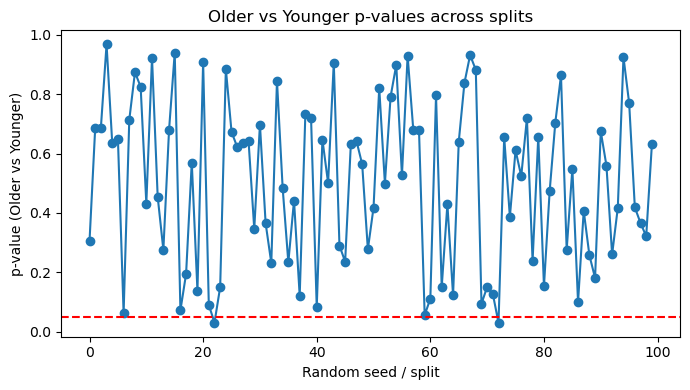

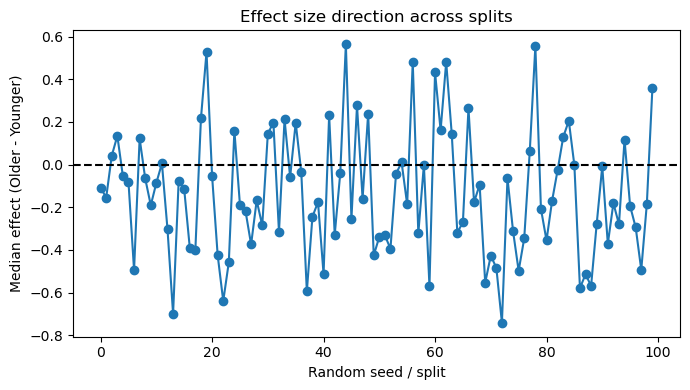

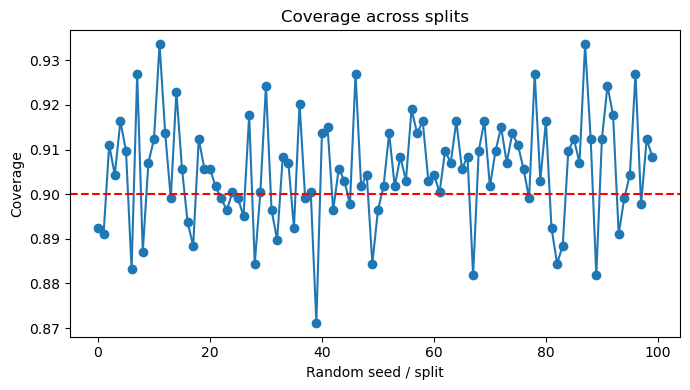

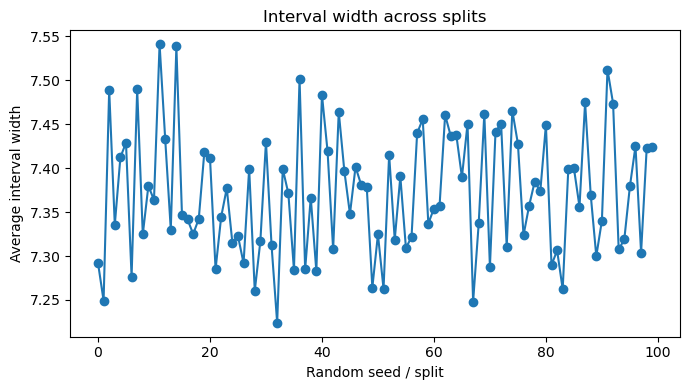

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================
MODEL_NAME = "Ridge"   # change if you want: "SVR", "ElasticNet", etc.
ALPHA = 0.1
N_SPLITS_CV = 5
TEST_SIZE = 0.2
SEEDS = list(range(100))   # 10 repetitions
PF_COL = "p_factor_mcelroy_harmonized_all_samples"

# sanity check
assert MODEL_NAME in models, f"{MODEL_NAME} not found in models. Available: {list(models.keys())}"
assert PF_COL in df_combined.columns, f"{PF_COL} not found in df_combined columns"

# =========================================================
# OPTIONAL: effect size function
# =========================================================
def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) == 0 or len(y) == 0:
        return np.nan

    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)

    return (gt - lt) / (len(x) * len(y))

# =========================================================
# RUN MULTIPLE SPLITS
# =========================================================
multi_split_results = []

for seed in SEEDS:
    print(f"\n==============================")
    print(f"Running split with random_state = {seed}")
    print(f"==============================")

    # ---- Run CV+ on this split ----
    out = cv_plus_conformal_regression(
        X, y, models[MODEL_NAME],
        dataset_name="ALL",
        model_name=MODEL_NAME,
        alpha=ALPHA,
        n_splits=N_SPLITS_CV,
        random_state=seed,
        save_folder="saved_models"
    )

    # ---- Extract interval results ----
    y_test = np.asarray(out["y_test"])
    lower = np.asarray(out["lower"])
    upper = np.asarray(out["upper"])

    # ---- Define covered / older / younger ----
    covered_mask = (y_test >= lower) & (y_test <= upper)
    older_mask   = y_test > upper    # true age ABOVE interval -> brain looks younger
    younger_mask = y_test < lower    # true age BELOW interval -> brain looks older

    # ---- Recreate EXACT same outer split for df_combined ----
    # This aligns p-factor with y_test from the same random_state split
    _, _, _, _, _, df_test = train_test_split(
        X, y, df_combined,
        test_size=TEST_SIZE,
        random_state=seed
    )

    # ---- Extract p-factor for test set ----
    p_test = df_test[PF_COL].values

    # ---- Get group values ----
    p_cov = p_test[covered_mask]
    p_old = p_test[older_mask]
    p_yng = p_test[younger_mask]

    # ---- Pairwise test: Older vs Younger (the key comparison) ----
    if len(p_old) > 1 and len(p_yng) > 1:
        _, p_val_old_vs_yng = mannwhitneyu(p_old, p_yng, alternative="two-sided")
    else:
        p_val_old_vs_yng = np.nan

    # ---- Optional: Covered vs Uncovered too ----
    p_unc = p_test[~covered_mask]
    if len(p_cov) > 1 and len(p_unc) > 1:
        _, p_val_cov_vs_unc = mannwhitneyu(p_cov, p_unc, alternative="two-sided")
    else:
        p_val_cov_vs_unc = np.nan

    # ---- Store results ----
    row = {
        "seed": seed,
        "model": MODEL_NAME,
        "rmse": out["rmse"],
        "r2": out["r2"],
        "coverage": out["coverage"],
        "avg_width": out["avg_width"],

        "n_test": len(y_test),
        "n_covered": int(covered_mask.sum()),
        "n_uncovered": int((~covered_mask).sum()),
        "n_older": int(older_mask.sum()),
        "n_younger": int(younger_mask.sum()),

        "median_p_covered": np.median(p_cov) if len(p_cov) else np.nan,
        "median_p_uncovered": np.median(p_unc) if len(p_unc) else np.nan,
        "median_p_older": np.median(p_old) if len(p_old) else np.nan,
        "median_p_younger": np.median(p_yng) if len(p_yng) else np.nan,

        "mean_p_covered": np.mean(p_cov) if len(p_cov) else np.nan,
        "mean_p_uncovered": np.mean(p_unc) if len(p_unc) else np.nan,
        "mean_p_older": np.mean(p_old) if len(p_old) else np.nan,
        "mean_p_younger": np.mean(p_yng) if len(p_yng) else np.nan,

        "p_old_vs_younger": p_val_old_vs_yng,
        "p_covered_vs_uncovered": p_val_cov_vs_unc,

        "median_effect_old_minus_young": (
            np.median(p_old) - np.median(p_yng)
            if len(p_old) and len(p_yng) else np.nan
        ),

        "cliffs_delta_old_vs_young": cliffs_delta(p_old, p_yng),
        "cliffs_delta_cov_vs_unc": cliffs_delta(p_cov, p_unc),
    }

    multi_split_results.append(row)

    # ---- Print split summary ----
    print(f"RMSE: {row['rmse']:.4f}")
    print(f"R2: {row['r2']:.4f}")
    print(f"Coverage: {row['coverage']:.4f}")
    print(f"Avg Width: {row['avg_width']:.4f}")
    print(f"Covered: {row['n_covered']} | Uncovered: {row['n_uncovered']}")
    print(f"Older: {row['n_older']} | Younger: {row['n_younger']}")
    print(f"Median p (older): {row['median_p_older']}")
    print(f"Median p (younger): {row['median_p_younger']}")
    print(f"Older vs Younger p-value: {row['p_old_vs_younger']}")
    print(f"Median effect (old - young): {row['median_effect_old_minus_young']}")
    print(f"Cliff's delta (old vs young): {row['cliffs_delta_old_vs_young']}")

# =========================================================
# RESULTS TABLE
# =========================================================
df_multi = pd.DataFrame(multi_split_results)

print("\n\n===== RESULTS ACROSS SPLITS =====")
print(df_multi)

# =========================================================
# SUMMARY / "POWER" STYLE VIEW
# =========================================================
print("\n\n===== SUMMARY =====")
print(df_multi.describe(include="all"))

# proportion of splits where the older-vs-younger result is significant
sig_rate_old_vs_yng = np.mean(df_multi["p_old_vs_younger"] < 0.05)
sig_rate_cov_vs_unc = np.mean(df_multi["p_covered_vs_uncovered"] < 0.05)

print("\nProportion significant (Older vs Younger):", sig_rate_old_vs_yng)
print("Proportion significant (Covered vs Uncovered):", sig_rate_cov_vs_unc)

print("\nAverage p-value (Older vs Younger):", df_multi["p_old_vs_younger"].mean())
print("Average median effect (Old - Young):", df_multi["median_effect_old_minus_young"].mean())
print("Average Cliff's delta (Old vs Young):", df_multi["cliffs_delta_old_vs_young"].mean())

# =========================================================
# OPTIONAL: SAVE RESULTS
# =========================================================
df_multi.to_csv("multi_split_power_results.csv", index=False)
print("\nSaved results to: multi_split_power_results.csv")

# =========================================================
# OPTIONAL: PLOTS
# =========================================================

# 1) p-values across splits
plt.figure(figsize=(7, 4))
plt.plot(df_multi["seed"], df_multi["p_old_vs_younger"], marker="o")
plt.axhline(0.05, linestyle="--", color="red")
plt.xlabel("Random seed / split")
plt.ylabel("p-value (Older vs Younger)")
plt.title("Older vs Younger p-values across splits")
plt.tight_layout()
plt.show()

# 2) median effect across splits
plt.figure(figsize=(7, 4))
plt.plot(df_multi["seed"], df_multi["median_effect_old_minus_young"], marker="o")
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Random seed / split")
plt.ylabel("Median effect (Older - Younger)")
plt.title("Effect size direction across splits")
plt.tight_layout()
plt.show()

# 3) coverage across splits
plt.figure(figsize=(7, 4))
plt.plot(df_multi["seed"], df_multi["coverage"], marker="o")
plt.axhline(0.90, linestyle="--", color="red")
plt.xlabel("Random seed / split")
plt.ylabel("Coverage")
plt.title("Coverage across splits")
plt.tight_layout()
plt.show()

# 4) interval width across splits
plt.figure(figsize=(7, 4))
plt.plot(df_multi["seed"], df_multi["avg_width"], marker="o")
plt.xlabel("Random seed / split")
plt.ylabel("Average interval width")
plt.title("Interval width across splits")
plt.tight_layout()
plt.show()

In [14]:
print("Proportion significant (Older vs Younger):", sig_rate_old_vs_yng)

Proportion significant (Older vs Younger): 0.02


In [15]:
print(df_multi["p_old_vs_younger"].describe())

count    100.000000
mean       0.503974
std        0.275620
min        0.029397
25%        0.259138
50%        0.537746
75%        0.699399
max        0.968358
Name: p_old_vs_younger, dtype: float64


In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEEDS = list(range(100))   # 100 splits
bin_width = 2  # you can change to 1 if needed

coverage_results = []

for seed in SEEDS:
    print(f"Running split {seed}")

    # ---- Run CV+ ----
    out = cv_plus_conformal_regression(
        X, y, models["Ridge"],
        dataset_name="ALL",
        model_name="Ridge",
        alpha=0.1,
        n_splits=5,
        random_state=seed
    )

    y_test = np.asarray(out["y_test"])
    lower = np.asarray(out["lower"])
    upper = np.asarray(out["upper"])
    

    # ---- Compute coverage mask ----
    covered_mask = (y_test >= lower) & (y_test <= upper)

    # ---- Create age bins ----
    min_age = int(np.floor(y_test.min()))
    max_age = int(np.ceil(y_test.max()))

    bins = np.arange(min_age, max_age + bin_width, bin_width)

    age_bins = pd.cut(y_test, bins=bins)

    # ---- Compute coverage per bin ----
    df_temp = pd.DataFrame({
        "age": y_test,
        "covered": covered_mask,
        "age_bin": age_bins
    })

    coverage_per_bin = df_temp.groupby("age_bin")["covered"].mean()

    # store
    for bin_label, cov in coverage_per_bin.items():
        coverage_results.append({
            "seed": seed,
            "age_bin": str(bin_label),
            "coverage": cov
        })

# convert to dataframe
df_cov = pd.DataFrame(coverage_results)

print(df_cov.head())

Running split 0


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:67: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipy

Running split 1


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:67: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipy

Running split 2


...

Running split 98


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:67: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipy

Running split 99


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:67: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipy

   seed   age_bin  coverage
0     0    (6, 8]  0.849315
1     0   (8, 10]  0.889706
2     0  (10, 12]  0.936709
3     0  (12, 14]  0.940171
4     0  (14, 16]  0.945652


### New code as per TED - could plot coverage vs. sample size to make this point directly?

In [10]:
import numpy as np
import pandas as pd

SEEDS = list(range(100))
bin_width = 2
coverage_results = []

for seed in SEEDS:
    print(f"Running split {seed}")
    out = cv_plus_conformal_regression(
        X, y, models["Ridge"],
        dataset_name="ALL", model_name="Ridge",
        alpha=0.1, n_splits=5, random_state=seed
    )
    y_test = np.asarray(out["y_test"])
    lower  = np.asarray(out["lower"])
    upper  = np.asarray(out["upper"])
    covered_mask = (y_test >= lower) & (y_test <= upper)

    min_age = int(np.floor(y_test.min()))
    max_age = int(np.ceil(y_test.max()))
    bins = np.arange(min_age, max_age + bin_width, bin_width)
    age_bins = pd.cut(y_test, bins=bins)

    df_temp = pd.DataFrame({"age": y_test, "covered": covered_mask, "age_bin": age_bins})
    grouped = df_temp.groupby("age_bin")["covered"]
    coverage_per_bin = grouped.mean()
    n_per_bin        = grouped.count()   # <-- NEW

    for bin_label in coverage_per_bin.index:
        coverage_results.append({
            "seed": seed,
            "age_bin": str(bin_label),
            "coverage": coverage_per_bin[bin_label],
            "n": int(n_per_bin[bin_label]),   # <-- NEW
        })

df_cov = pd.DataFrame(coverage_results)
print(df_cov.head())

Running split 0


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:67: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipy

Running split 1


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:67: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipy

Running split 2


...

Running split 98


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:67: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipy

Running split 99


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:67: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_32103/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipy

   seed   age_bin  coverage    n
0     0    (6, 8]  0.849315   73
1     0   (8, 10]  0.889706  136
2     0  (10, 12]  0.936709  158
3     0  (12, 14]  0.940171  117
4     0  (14, 16]  0.945652   92


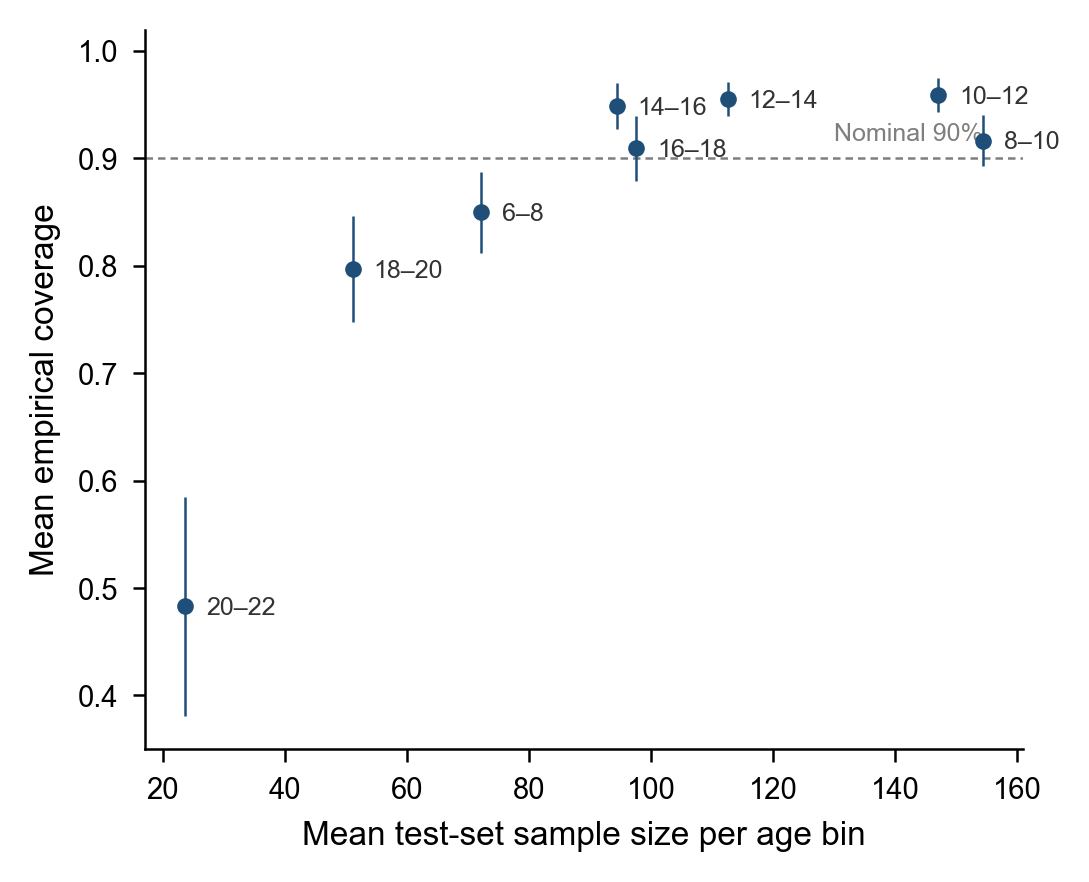

saved figure3B_coverage_vs_n.png (600 dpi) and .pdf


In [15]:
"""
Figure 3B - Coverage vs. sample size per age bin.
Nature-style: clean, minimal, Arial-family sans-serif, no chartjunk.
Expects df_cov with columns: seed, age_bin, coverage, n
"""
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

# ----- Nature-style rc params -----
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# ----- Aggregate df_cov -----
# df_cov must exist in the notebook (from your earlier loop)
summary = (df_cov.groupby("age_bin", observed=True)
                 .agg(mean_coverage=("coverage", "mean"),
                      sd_coverage=("coverage", "std"),
                      mean_n=("n", "mean"))
                 .reset_index())
summary["bin_start"] = summary["age_bin"].str.extract(r"\((\d+)").astype(int)
summary = summary.sort_values("bin_start").reset_index(drop=True)

# ----- Figure: single column (~89 mm) -----
fig, ax = plt.subplots(figsize=(3.5, 2.8), dpi=300)

# Data points
ax.errorbar(summary["mean_n"], summary["mean_coverage"],
            yerr=summary["sd_coverage"],
            fmt="o", color="#1f4e79", ecolor="#1f4e79",
            capsize=1.8, capthick=0.6,
            markersize=4, markeredgewidth=0,
            elinewidth=0.6, zorder=3)

# Nominal 90% line
ax.axhline(0.90, linestyle=(0, (3, 2)), color="#7f7f7f",
           linewidth=0.6, zorder=1)

# Age-bin labels — offset so they don't overlap the point
for _, r in summary.iterrows():
    label = r["age_bin"].replace("(", "").replace("]", "").replace(", ", "–")
    ax.annotate(label, (r["mean_n"], r["mean_coverage"]),
                xytext=(5, -2), textcoords="offset points",
                fontsize=6, color="#333", zorder=4)

# "Nominal 90%" annotation
ax.annotate("Nominal 90%", xy=(summary["mean_n"].max(), 0.90),
            xytext=(0, 3), textcoords="offset points",
            ha="right", va="bottom", fontsize=6, color="#7f7f7f")

# Axes
ax.set_xlabel("Mean test-set sample size per age bin")
ax.set_ylabel("Mean empirical coverage")
ax.set_ylim(0.35, 1.02)

# Remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(pad=0.3)
plt.savefig("figure3B_coverage_vs_n.png", dpi=600,
            bbox_inches="tight", facecolor="white")
plt.savefig("figure3B_coverage_vs_n.pdf",
            bbox_inches="tight", facecolor="white")
plt.show()
print("saved figure3B_coverage_vs_n.png (600 dpi) and .pdf")

### +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

<Figure size 2700x1500 with 0 Axes>

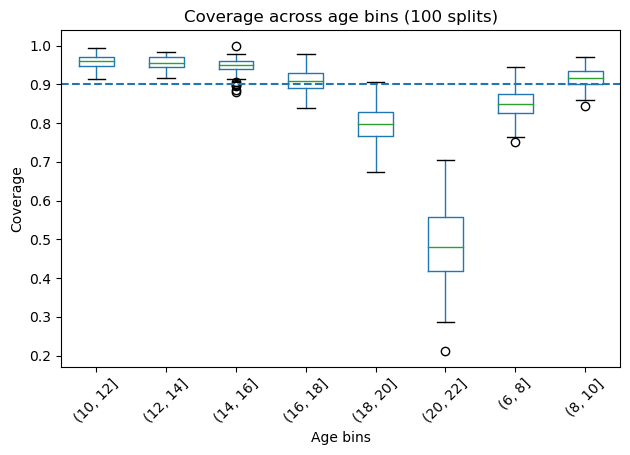

In [18]:
import matplotlib.pyplot as plt

# sort bins properly
df_cov["age_bin"] = pd.Categorical(
    df_cov["age_bin"],
    categories=sorted(df_cov["age_bin"].unique()),
    ordered=True
)

plt.figure(figsize=(9,5), dpi=300)

# boxplot
df_cov.boxplot(
    column="coverage",
    by="age_bin",
    grid=False
)

# reference line (important)
plt.axhline(0.90, linestyle="--")

# labels
plt.xlabel("Age bins")
plt.ylabel("Coverage")
plt.title("Coverage across age bins (100 splits)")
plt.suptitle("")  # remove automatic title

# rotate labels for readability
plt.xticks(rotation=45)

# tighten layout
plt.tight_layout()

plt.show()

In [19]:
df_cov.groupby("age_bin")["coverage"].mean()

age_bin
(10, 12]    0.959010
(12, 14]    0.955586
(14, 16]    0.948978
(16, 18]    0.909402
(18, 20]    0.797038
(20, 22]    0.483011
(6, 8]      0.849704
(8, 10]     0.916507
Name: coverage, dtype: float64

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

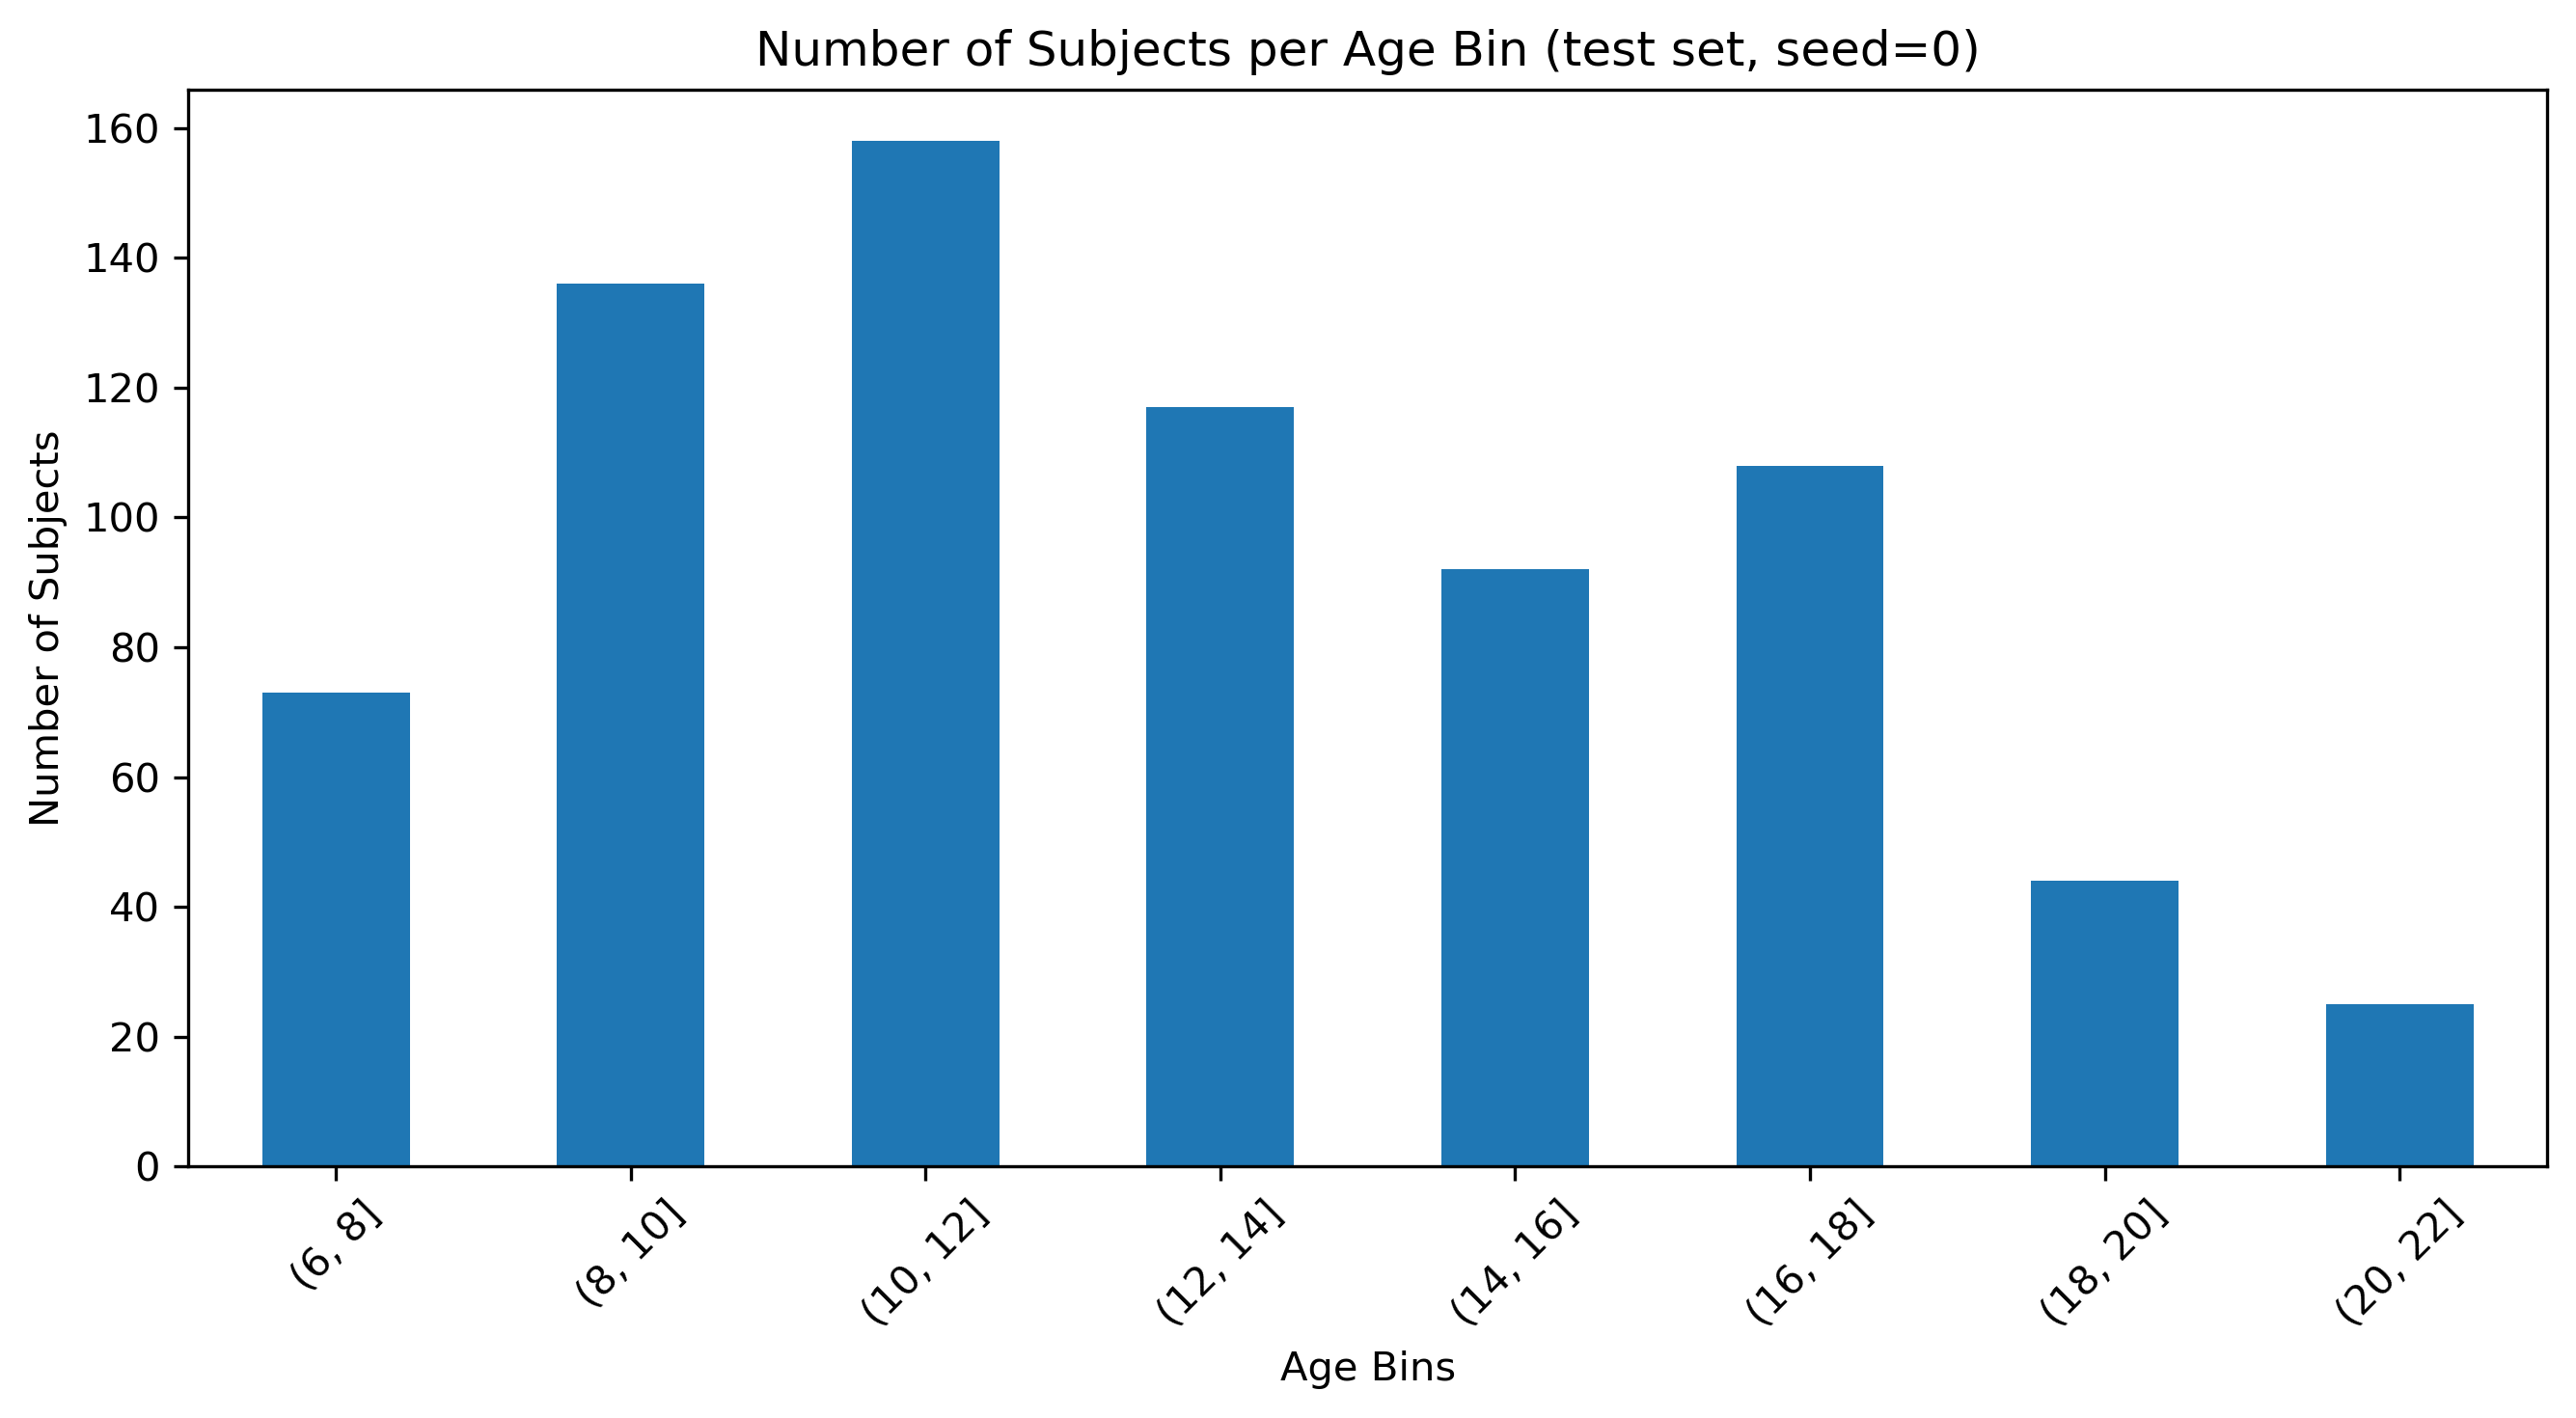

(6, 8]       73
(8, 10]     136
(10, 12]    158
(12, 14]    117
(14, 16]     92
(16, 18]    108
(18, 20]     44
(20, 22]     25
dtype: int64


In [20]:
# Count subjects per age bin (using seed=0 as representative split)
out_sample = cv_plus_conformal_regression(
    X, y, models["Ridge"],
    dataset_name="ALL",
    model_name="Ridge",
    alpha=0.1,
    n_splits=5,
    random_state=0
)

y_test_sample = np.asarray(out_sample["y_test"])

# Create same bins as coverage plot
bin_width = 2
min_age = int(np.floor(y_test_sample.min()))
max_age = int(np.ceil(y_test_sample.max()))
bins = np.arange(min_age, max_age + bin_width, bin_width)

# Count people per bin
age_bins = pd.cut(y_test_sample, bins=bins)
bin_counts = pd.Series(age_bins).value_counts(sort=False).sort_index()

# Plot
plt.figure(figsize=(9, 5), dpi=300)
bin_counts.plot(kind='bar')
plt.xlabel("Age Bins")
plt.ylabel("Number of Subjects")
plt.title("Number of Subjects per Age Bin (test set, seed=0)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print counts
print(bin_counts)

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

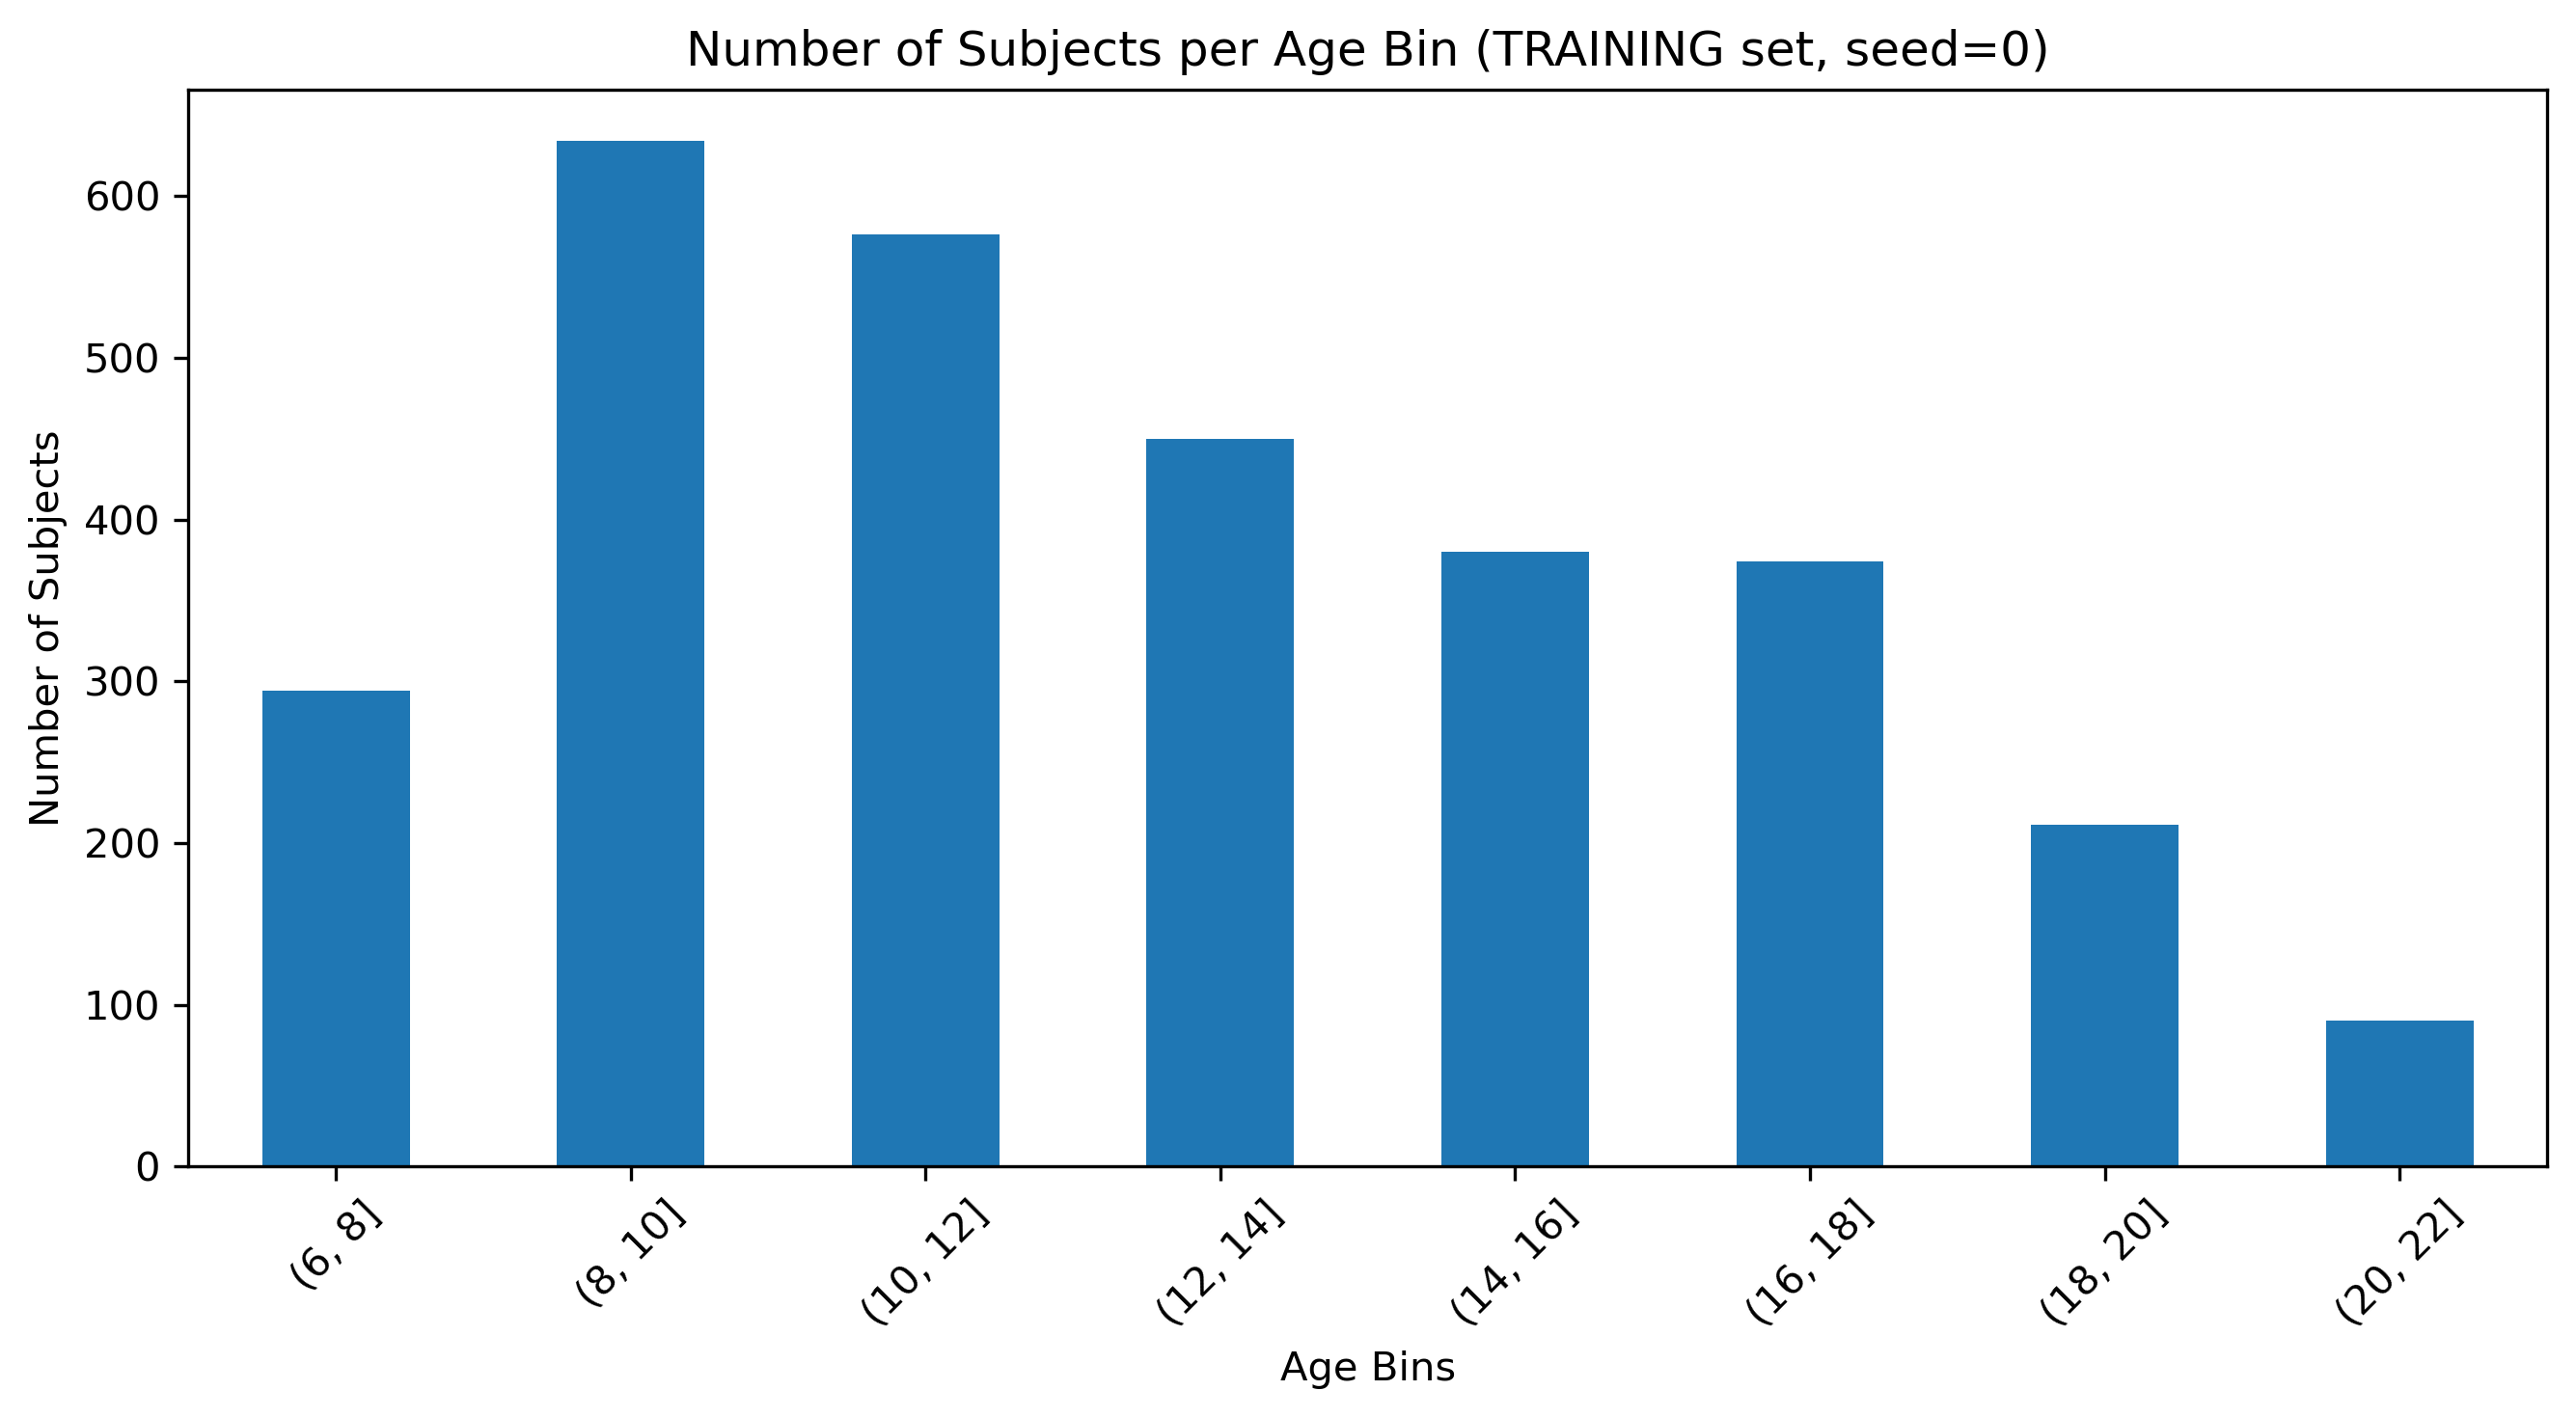

(6, 8]      294
(8, 10]     634
(10, 12]    576
(12, 14]    450
(14, 16]    380
(16, 18]    374
(18, 20]    211
(20, 22]     90
dtype: int64

Total training subjects: 3009


In [22]:
# Count subjects per age bin for TRAINING set (seed=0)
out_sample = cv_plus_conformal_regression(
    X, y, models["Ridge"],
    dataset_name="ALL",
    model_name="Ridge",
    alpha=0.1,
    n_splits=5,
    random_state=0
)

# Get training set ages
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

y_train_sample = np.asarray(y_train)

# Create same bins
bin_width = 2
min_age = int(np.floor(y_train_sample.min()))
max_age = int(np.ceil(y_train_sample.max()))
bins = np.arange(min_age, max_age + bin_width, bin_width)

# Count per bin
age_bins_train = pd.cut(y_train_sample, bins=bins)
bin_counts_train = pd.Series(age_bins_train).value_counts(sort=False).sort_index()

# Plot
plt.figure(figsize=(9, 5), dpi=300)
bin_counts_train.plot(kind='bar')
plt.xlabel("Age Bins")
plt.ylabel("Number of Subjects")
plt.title("Number of Subjects per Age Bin (TRAINING set, seed=0)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print
print(bin_counts_train)
print(f"\nTotal training subjects: {bin_counts_train.sum()}")

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

...

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:60: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_15533/2209794537.py:59: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/

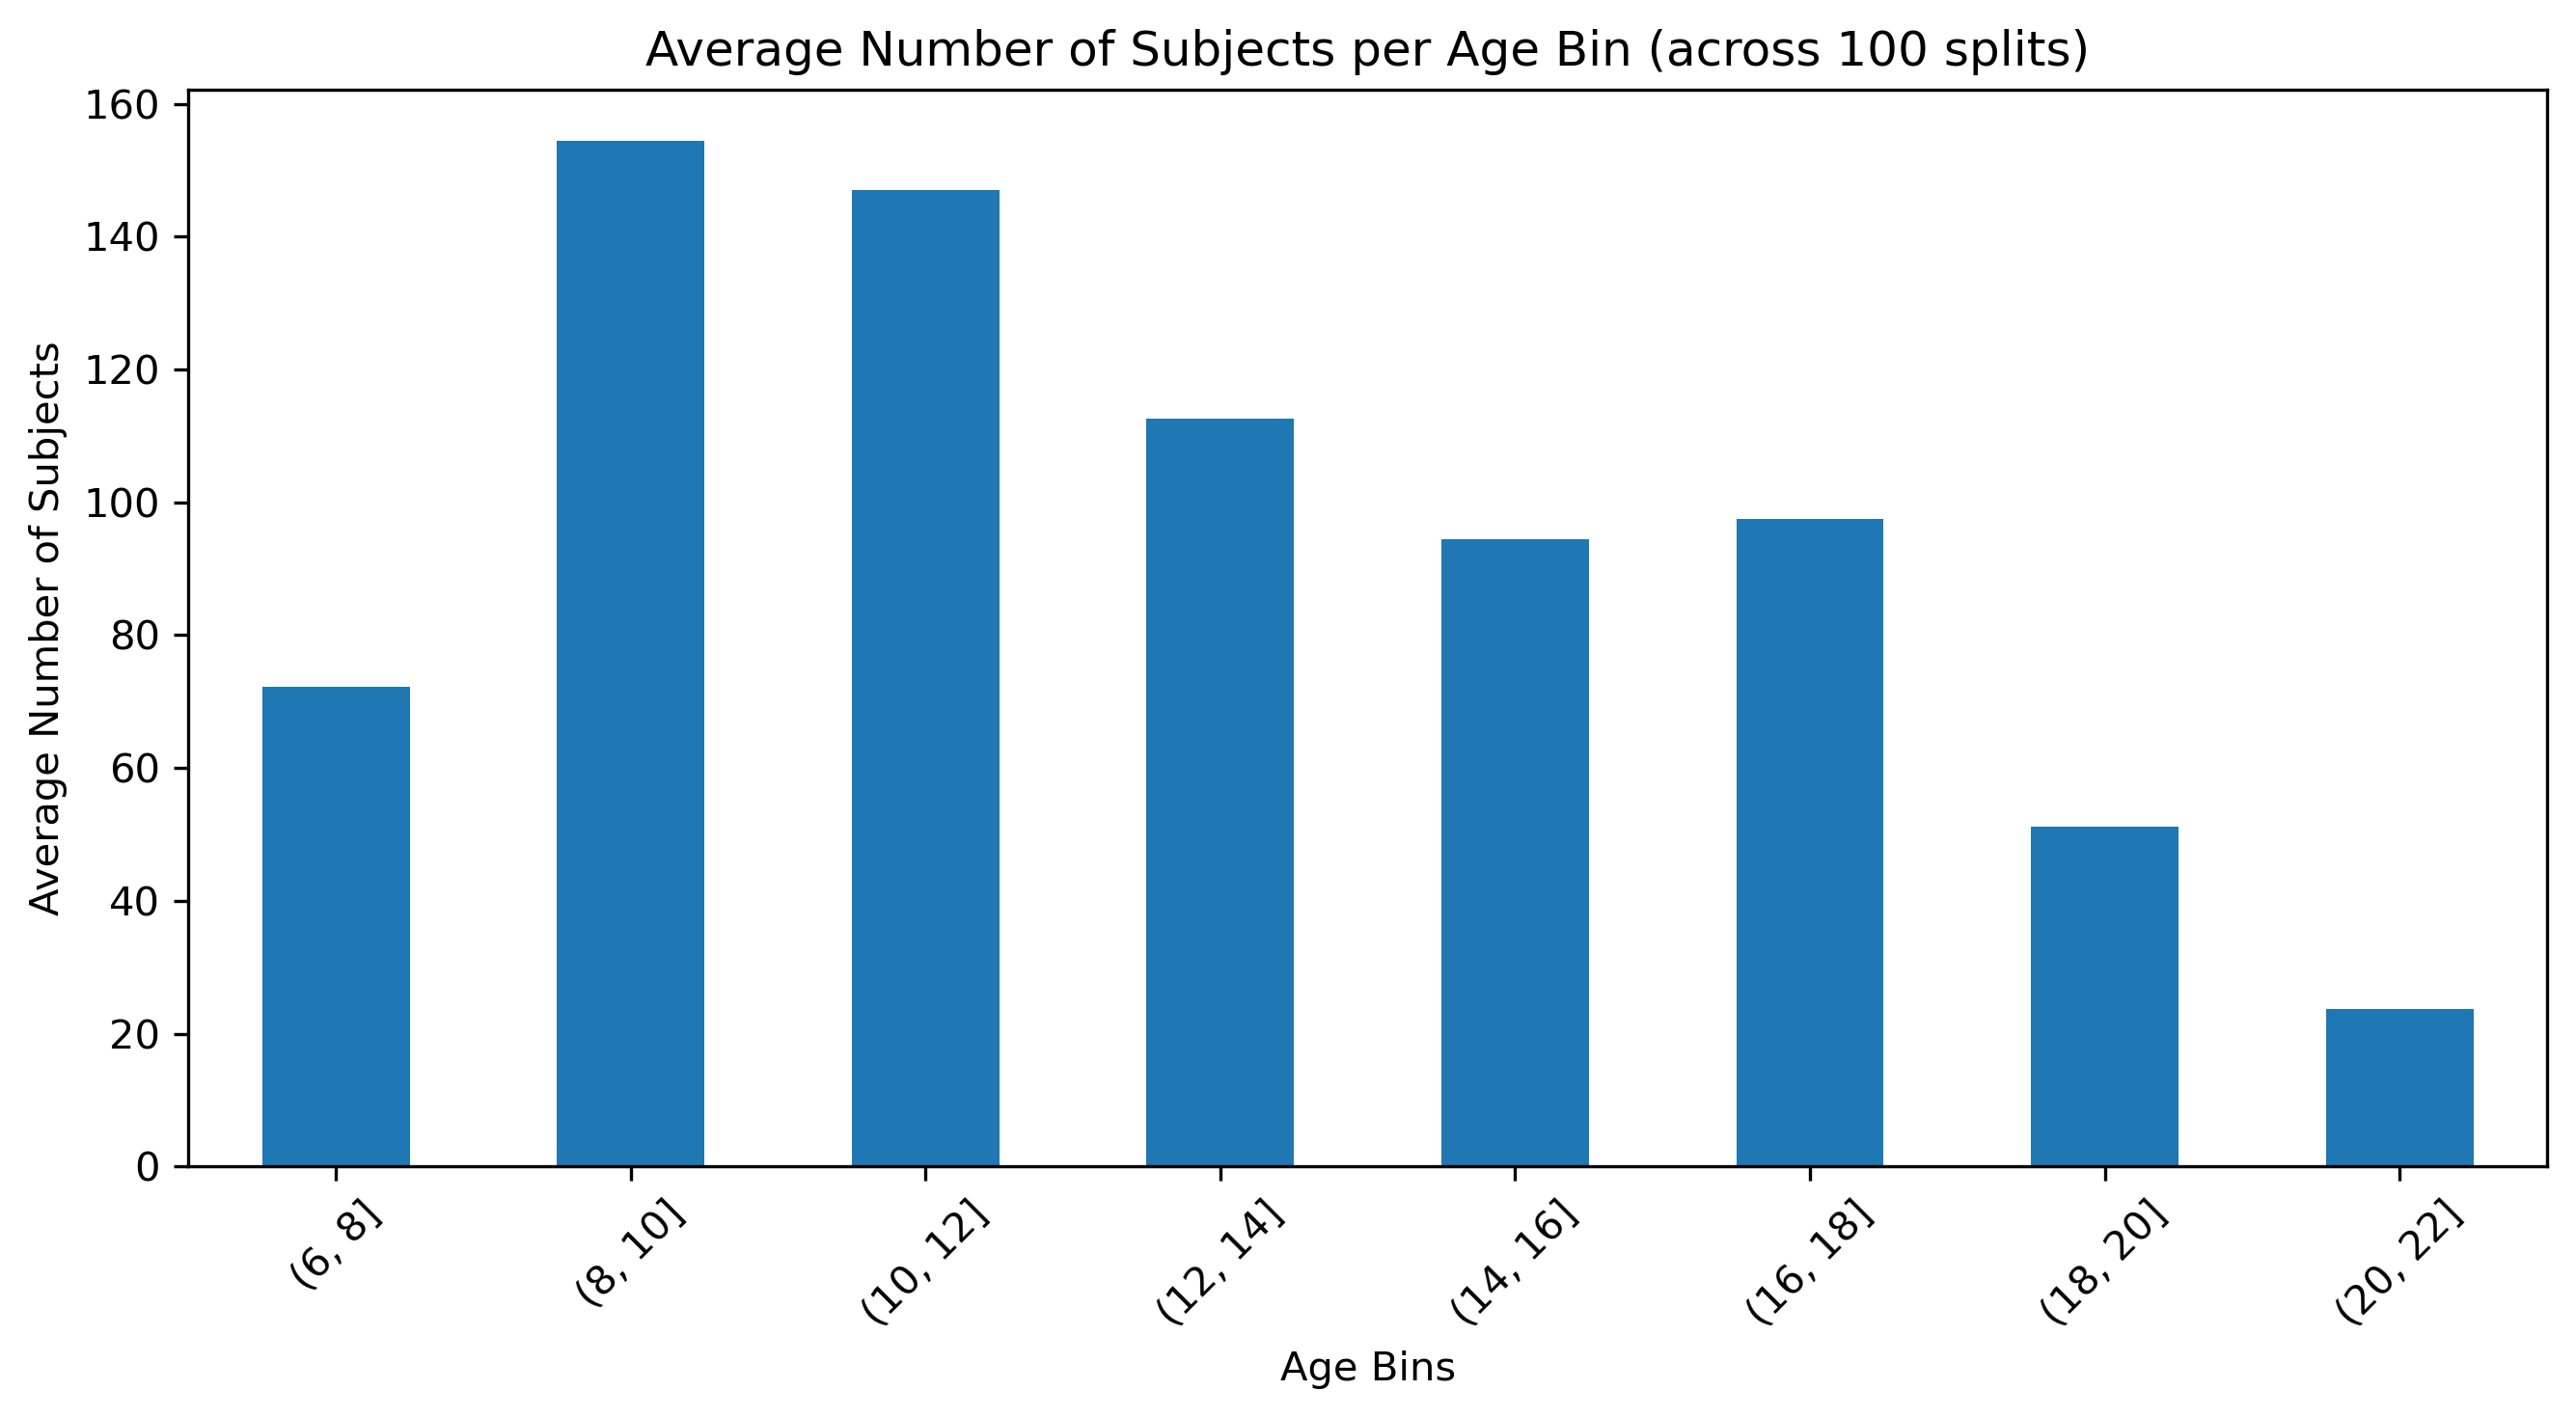

(6, 8]       72.20
(8, 10]     154.41
(10, 12]    147.05
(12, 14]    112.56
(14, 16]     94.42
(16, 18]     97.54
(18, 20]     51.12
(20, 22]     23.70
dtype: float64

Total average subjects per split: 753.0


In [21]:
# Average count per age bin across all 100 splits
bin_counts_all = []

for seed in SEEDS:
    out_s = cv_plus_conformal_regression(
        X, y, models["Ridge"],
        dataset_name="ALL",
        model_name="Ridge",
        alpha=0.1,
        n_splits=5,
        random_state=seed
    )
    
    y_test_s = np.asarray(out_s["y_test"])
    
    # same bins
    bin_width = 2
    min_age = int(np.floor(y_test_s.min()))
    max_age = int(np.ceil(y_test_s.max()))
    bins = np.arange(min_age, max_age + bin_width, bin_width)
    
    age_bins = pd.cut(y_test_s, bins=bins)
    counts = pd.Series(age_bins).value_counts(sort=False).sort_index()
    counts.name = seed
    bin_counts_all.append(counts)

# combine all 100 splits
df_bin_counts = pd.DataFrame(bin_counts_all)

# average across 100 splits
avg_counts = df_bin_counts.mean().sort_index()

# Plot
plt.figure(figsize=(9, 5), dpi=300)
avg_counts.plot(kind='bar')
plt.xlabel("Age Bins")
plt.ylabel("Average Number of Subjects")
plt.title("Average Number of Subjects per Age Bin (across 100 splits)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print
print(avg_counts)
print(f"\nTotal average subjects per split: {avg_counts.sum():.1f}")

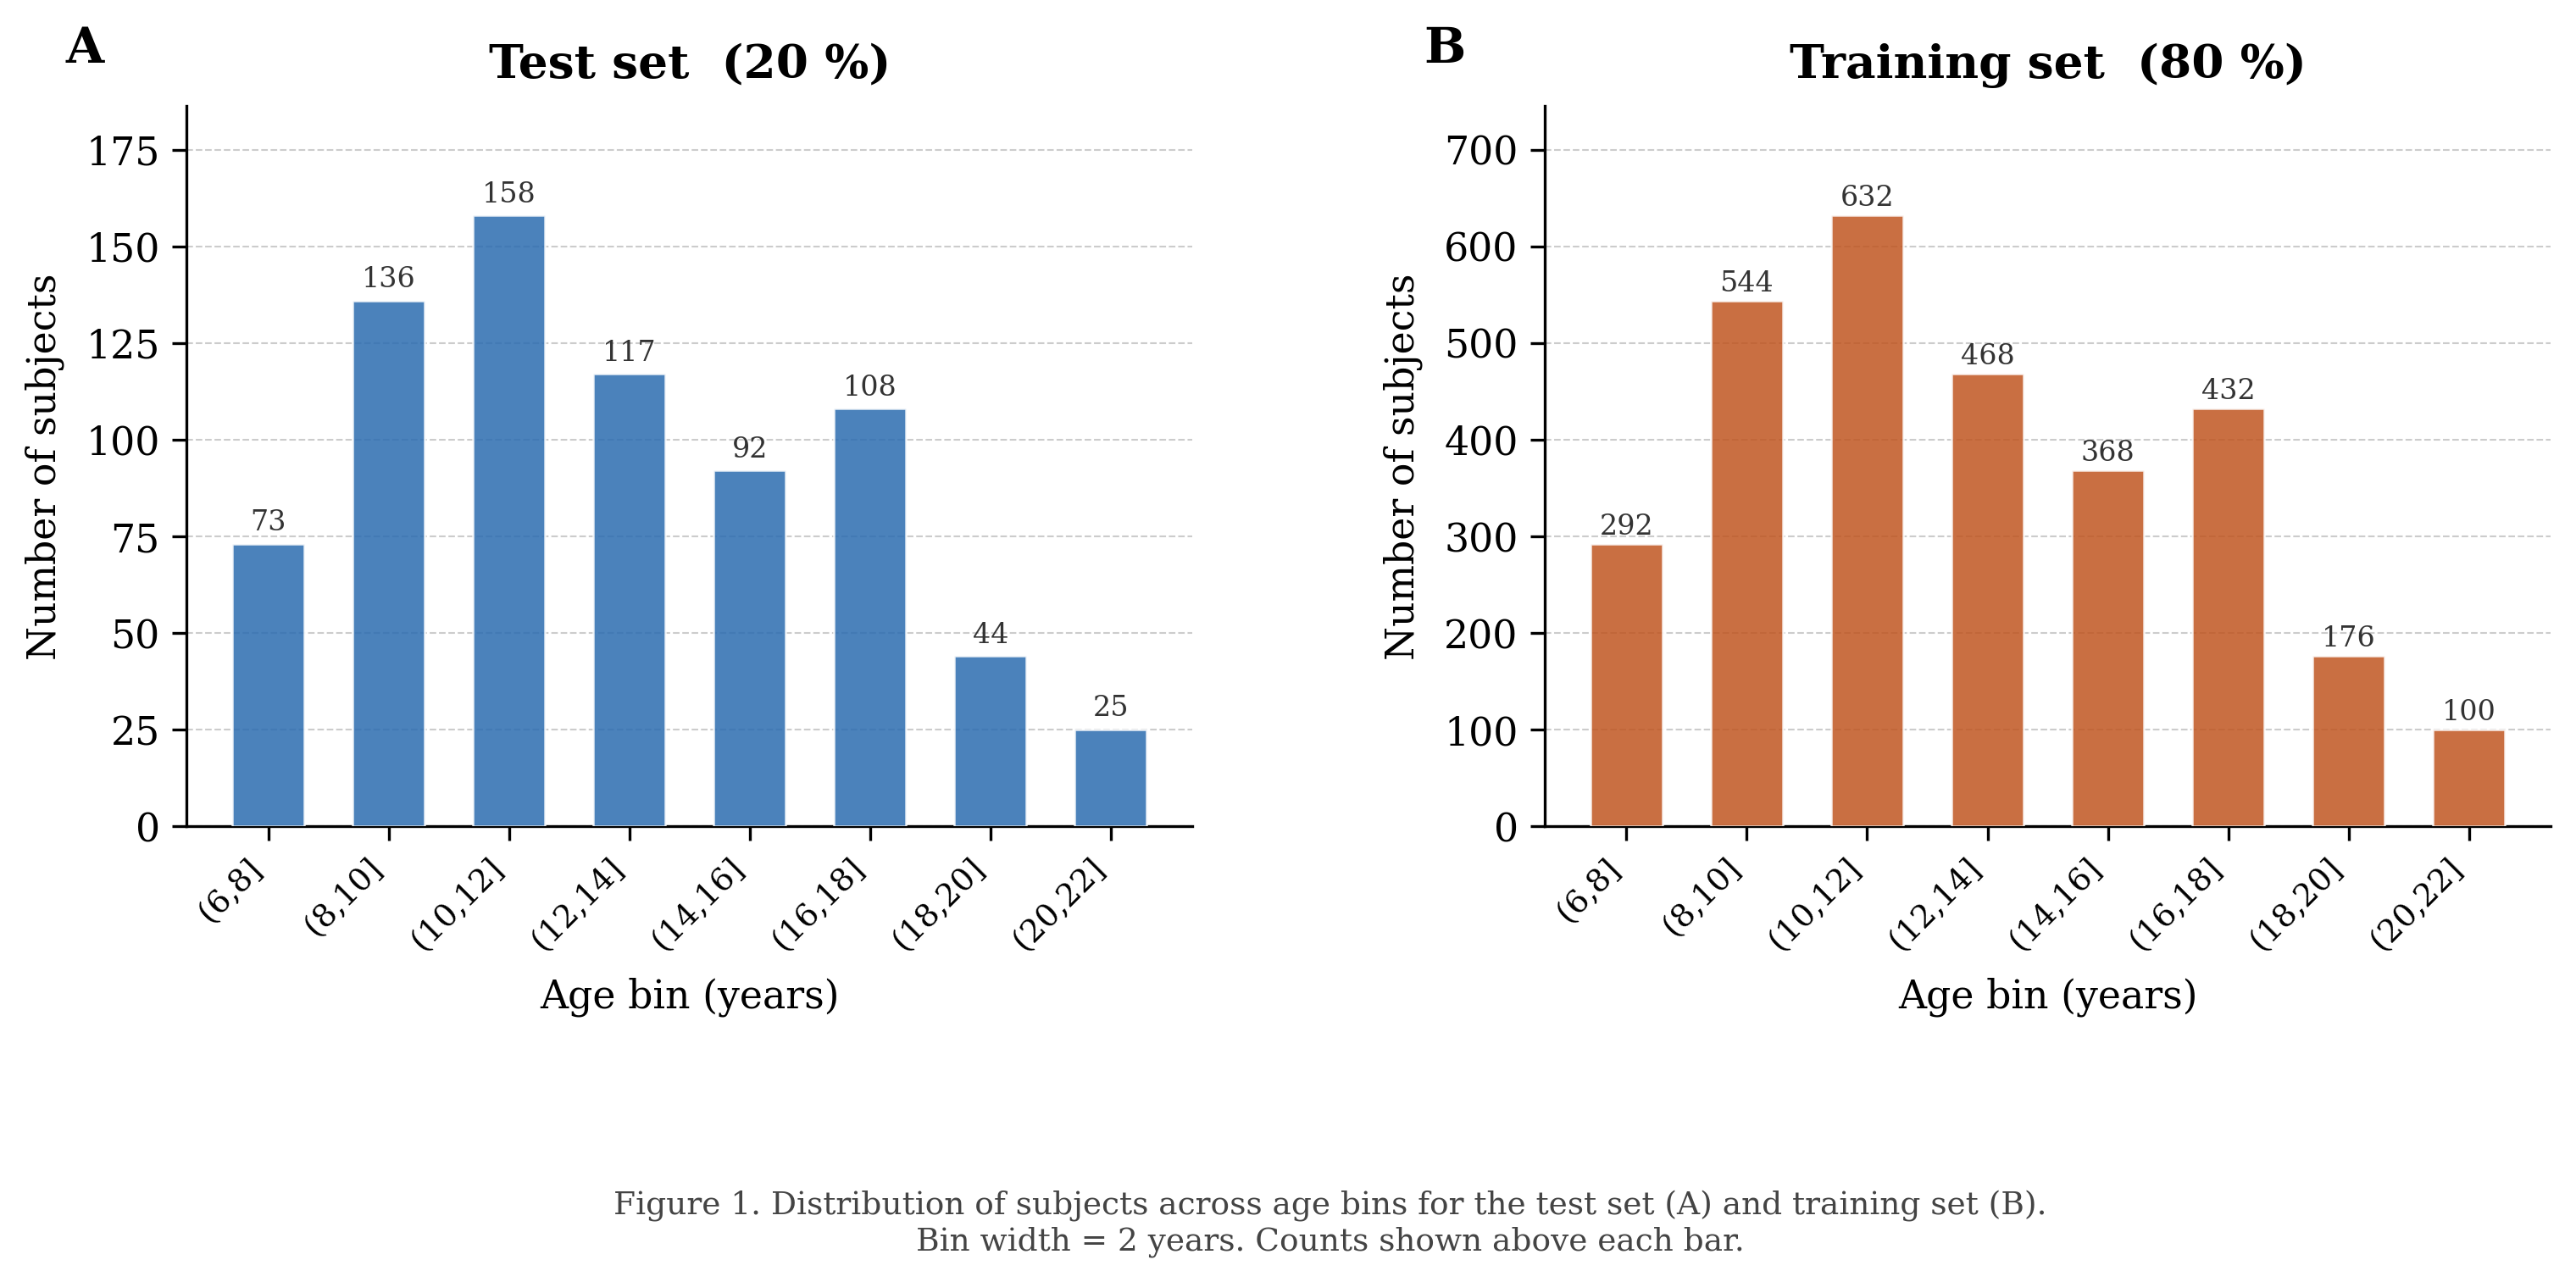

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# ── your data ──────────────────────────────────────────────
test_bins    = ['(6,8]','(8,10]','(10,12]','(12,14]','(14,16]','(16,18]','(18,20]','(20,22]']
test_counts  = [73, 136, 158, 117, 92, 108, 44, 25]
# replace with your actual training counts once you run the code
train_counts = [292, 544, 632, 468, 368, 432, 176, 100]   # ← swap with real values

# ── style ──────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'serif',
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.linewidth':   0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

BLUE  = '#2B6CB0'
CORAL = '#C05621'
GRID  = dict(color='#cccccc', linewidth=0.5, linestyle='--', zorder=0)

x     = np.arange(len(test_bins))
width = 0.6

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=300)
fig.subplots_adjust(wspace=0.35)

# ── panel A – test set ─────────────────────────────────────
ax = axes[0]
bars = ax.bar(x, test_counts, width=width, color=BLUE, alpha=0.85,
              edgecolor='white', linewidth=0.6, zorder=3)
ax.grid(axis='y', **GRID)
ax.set_xticks(x)
ax.set_xticklabels(test_bins, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Age bin (years)', labelpad=6)
ax.set_ylabel('Number of subjects', labelpad=6)
ax.set_title('Test set  (20 %)', fontweight='bold', pad=8)
ax.text(-0.12, 1.06, 'A', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
for bar, val in zip(bars, test_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=8, color='#333333')
ax.set_ylim(0, max(test_counts) * 1.18)

# ── panel B – training set ─────────────────────────────────
ax = axes[1]
bars = ax.bar(x, train_counts, width=width, color=CORAL, alpha=0.85,
              edgecolor='white', linewidth=0.6, zorder=3)
ax.grid(axis='y', **GRID)
ax.set_xticks(x)
ax.set_xticklabels(test_bins, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Age bin (years)', labelpad=6)
ax.set_ylabel('Number of subjects', labelpad=6)
ax.set_title('Training set  (80 %)', fontweight='bold', pad=8)
ax.text(-0.12, 1.06, 'B', transform=ax.transAxes,
        fontsize=14, fontweight='bold')
for bar, val in zip(bars, train_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(val), ha='center', va='bottom', fontsize=8, color='#333333')
ax.set_ylim(0, max(train_counts) * 1.18)

# ── shared caption ─────────────────────────────────────────
fig.text(0.5, -0.12,
         'Figure 1. Distribution of subjects across age bins for the test set (A) and training set (B).\n'
         'Bin width = 2 years. Counts shown above each bar.',
         ha='center', fontsize=9, color='#444444')

plt.subplots_adjust(bottom=0.25)  # ← adds space at bottom for labels
plt.savefig('age_bin_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### New comaparison - Let’s try younger vs covered/older and older vs covered/younger.

In [48]:
from scipy.stats import ttest_ind, mannwhitneyu
import pandas as pd
import numpy as np

# 1. Select model output
out = results_full_all_cvplus["Ridge"]

y_test = out["y_test"]
lower = out["lower"]
upper = out["upper"]

# 2. Create covered / older / younger masks
covered_mask = (y_test >= lower) & (y_test <= upper)
older_mask = y_test > upper
younger_mask = y_test < lower

# 3. Align df_test with y_test index
# Use your actual merged dataframe name
df_test = df_combined.loc[y_test.index].copy()

# 4. Set correct p-factor column name
PF_COL = "p_factor_mcelroy_harmonized_all_samples"

# Optional check
print("Using p-factor column:", PF_COL)
print("p-factor column exists:", PF_COL in df_test.columns)

# 5. Add 3-class group labels
df_test["group_3class"] = np.where(
    covered_mask,
    "Covered",
    np.where(older_mask, "Older", "Younger")
)

print("\nGroup counts:")
print(df_test["group_3class"].value_counts())

# 6. Create professor-requested binary groups

# Younger vs Covered/Older
df_test["younger_vs_rest"] = np.where(
    younger_mask,
    "Younger",
    "Covered_or_Older"
)

# Older vs Covered/Younger
df_test["older_vs_rest"] = np.where(
    older_mask,
    "Older",
    "Covered_or_Younger"
)

# 7. Younger vs Covered/Older p-factor comparison
younger_pf = df_test.loc[
    df_test["younger_vs_rest"] == "Younger", PF_COL
].dropna()

rest_y_pf = df_test.loc[
    df_test["younger_vs_rest"] == "Covered_or_Older", PF_COL
].dropna()

print("\nYounger vs Covered/Older")
print("Younger n:", len(younger_pf))
print("Covered/Older n:", len(rest_y_pf))

if len(younger_pf) > 1 and len(rest_y_pf) > 1:
    print("T-test:", ttest_ind(younger_pf, rest_y_pf, equal_var=False))
    print("Mann-Whitney:", mannwhitneyu(younger_pf, rest_y_pf, alternative="two-sided"))
else:
    print("Not enough samples for statistical test.")

# 8. Older vs Covered/Younger p-factor comparison
older_pf = df_test.loc[
    df_test["older_vs_rest"] == "Older", PF_COL
].dropna()

rest_o_pf = df_test.loc[
    df_test["older_vs_rest"] == "Covered_or_Younger", PF_COL
].dropna()

print("\nOlder vs Covered/Younger")
print("Older n:", len(older_pf))
print("Covered/Younger n:", len(rest_o_pf))

if len(older_pf) > 1 and len(rest_o_pf) > 1:
    print("T-test:", ttest_ind(older_pf, rest_o_pf, equal_var=False))
    print("Mann-Whitney:", mannwhitneyu(older_pf, rest_o_pf, alternative="two-sided"))
else:
    print("Not enough samples for statistical test.")

Using p-factor column: p_factor_mcelroy_harmonized_all_samples
p-factor column exists: True

Group counts:
Covered    675
Older       55
Younger     23
Name: group_3class, dtype: int64

Younger vs Covered/Older
Younger n: 23
Covered/Older n: 730
T-test: Ttest_indResult(statistic=0.8438882559594592, pvalue=0.407227294682588)
Mann-Whitney: MannwhitneyuResult(statistic=9325.5, pvalue=0.36509960287889043)

Older vs Covered/Younger
Older n: 55
Covered/Younger n: 698
T-test: Ttest_indResult(statistic=0.14811052143172942, pvalue=0.8827256273530915)
Mann-Whitney: MannwhitneyuResult(statistic=19522.5, pvalue=0.8331984198722613)


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL_NAME = "Ridge"
ALPHA = 0.1
N_SPLITS_CV = 5
TEST_SIZE = 0.2
SEEDS = list(range(100))

age_bins = [6, 8, 10, 12, 14, 16, 18, 20, 22]
age_bin_order = [
    "(6, 8]",
    "(8, 10]",
    "(10, 12]",
    "(12, 14]",
    "(14, 16]",
    "(16, 18]",
    "(18, 20]",
    "(20, 22]"
]

coverage_records = []

for seed in SEEDS:
    print(f"Running split {seed}")

    out = cv_plus_conformal_regression(
        X, y, models[MODEL_NAME],
        dataset_name="ALL",
        model_name=MODEL_NAME,
        alpha=ALPHA,
        n_splits=N_SPLITS_CV,
        test_size=TEST_SIZE,
        random_state=seed,
        save_folder="saved_models"
    )

    y_test = out["y_test"]
    lower = out["lower"]
    upper = out["upper"]

    covered = ((y_test >= lower) & (y_test <= upper)).astype(int)

    temp_df = pd.DataFrame({
        "chronological_age": y_test.values,
        "covered": covered
    })

    temp_df["age_bin"] = pd.cut(
        temp_df["chronological_age"],
        bins=age_bins
    )

    coverage_by_bin = (
        temp_df.groupby("age_bin")["covered"]
        .mean()
        .reset_index()
    )

    coverage_by_bin["seed"] = seed
    coverage_records.append(coverage_by_bin)

df_cov = pd.concat(coverage_records, ignore_index=True)

df_cov["age_bin"] = df_cov["age_bin"].astype(str)
df_cov["age_bin"] = pd.Categorical(
    df_cov["age_bin"],
    categories=age_bin_order,
    ordered=True
)

df_cov = df_cov.sort_values("age_bin")

print(df_cov.head())

Running split 0


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10380/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10380/982750994.py:67: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10380/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipy

Running split 1


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10380/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10380/982750994.py:67: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10380/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipy

Running split 2


...

Running split 7


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10380/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10380/982750994.py:67: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10380/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipy

Running split 8


/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10380/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10380/982750994.py:67: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  upper_k = y_test_pred_k[None, :] + resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_10380/982750994.py:66: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  lower_k = y_test_pred_k[None, :] - resid[:, None]
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipy

KeyboardInterrupt: 

In [53]:
coverage_summary = (
    df_cov.groupby("age_bin")["covered"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
)

print(coverage_summary)

    age_bin      mean       std       min       max  count
0    (6, 8]  0.849704  0.037434  0.750000  0.943662    100
1   (8, 10]  0.916507  0.023454  0.843537  0.969697    100
2  (10, 12]  0.959010  0.016141  0.915033  0.993243    100
3  (12, 14]  0.955586  0.015963  0.917355  0.983471    100
4  (14, 16]  0.948978  0.021456  0.879121  1.000000    100
5  (16, 18]  0.909402  0.030064  0.839623  0.979592    100
6  (18, 20]  0.797038  0.049166  0.673913  0.906977    100
7  (20, 22]  0.483011  0.102136  0.210526  0.705882    100


<Figure size 3000x1500 with 0 Axes>

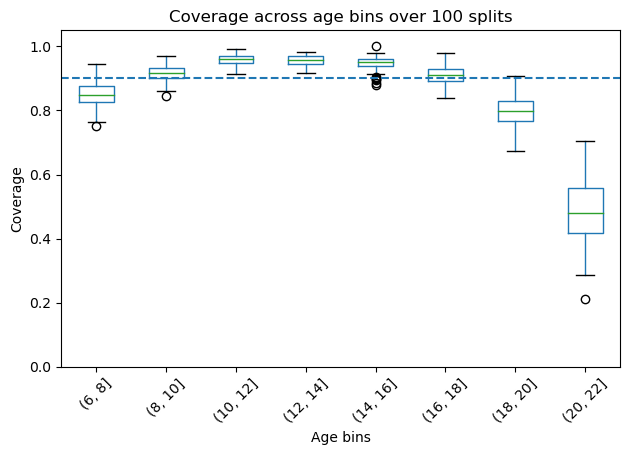

In [54]:
plt.figure(figsize=(10, 5), dpi=300)

df_cov.boxplot(
    column="covered",
    by="age_bin",
    grid=False
)

plt.axhline(0.90, linestyle="--")

plt.title("Coverage across age bins over 100 splits")
plt.suptitle("")
plt.xlabel("Age bins")
plt.ylabel("Coverage")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

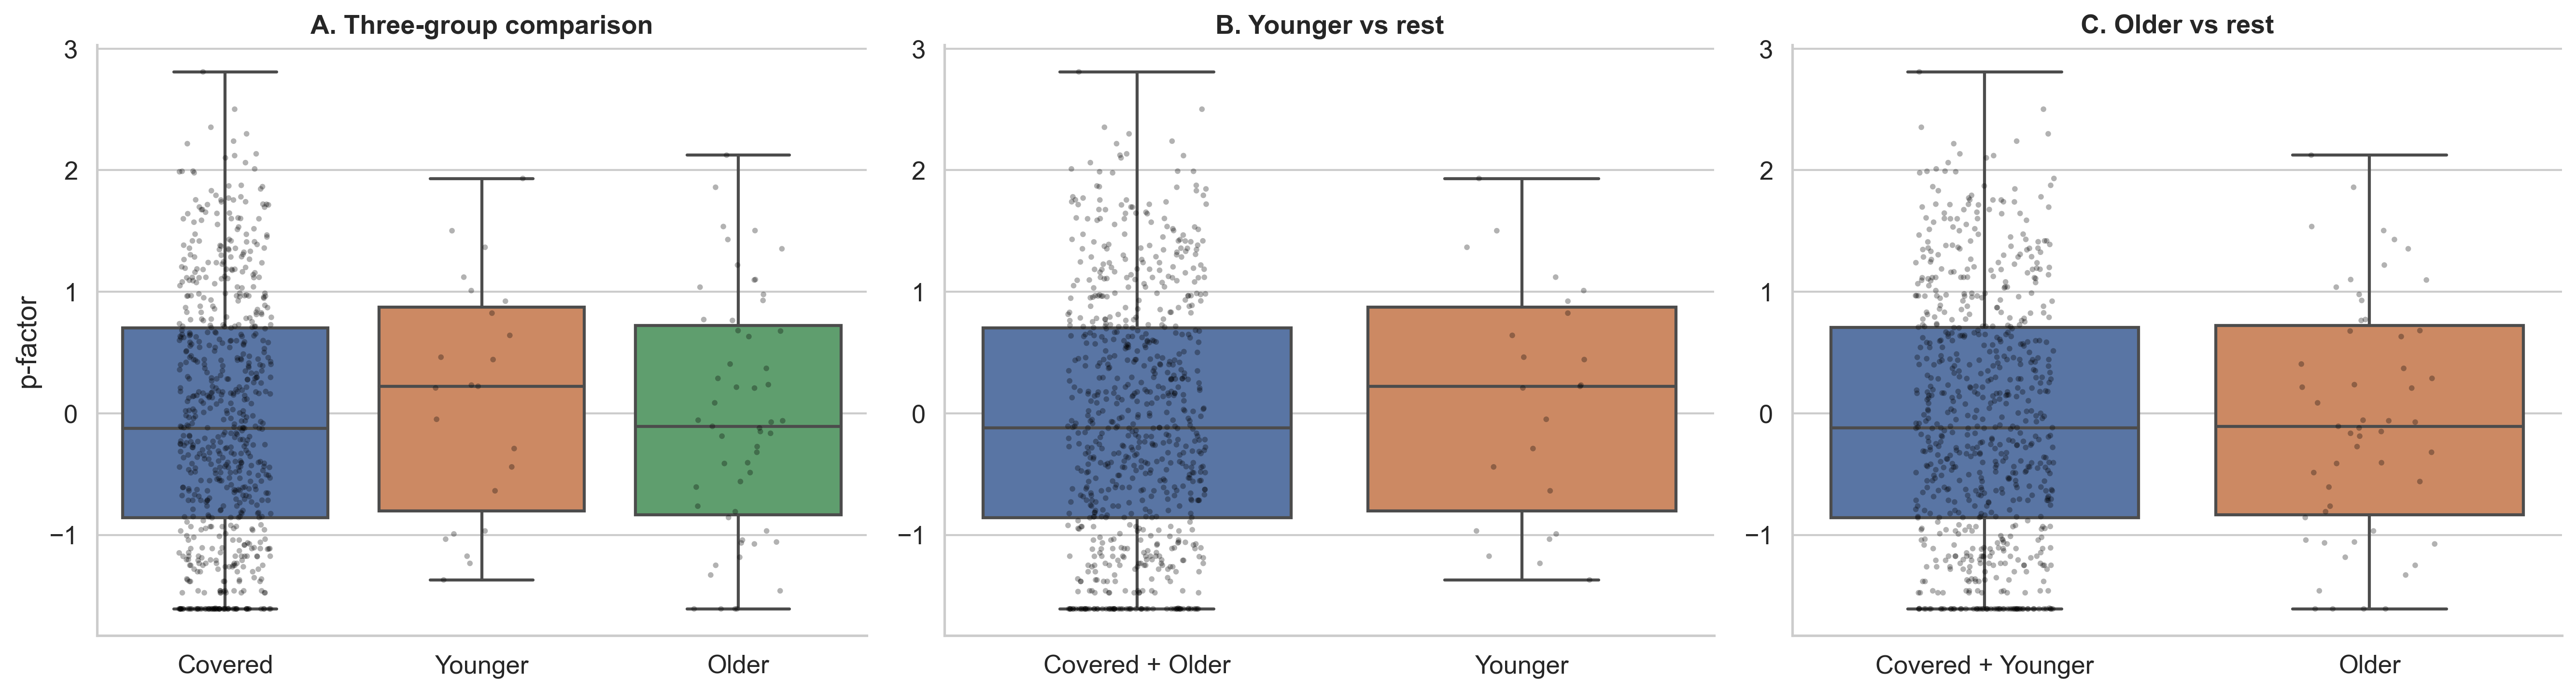

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.15)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

box_kws = dict(
    linewidth=1.5,
    fliersize=3
)

strip_kws = dict(
    color="black",
    alpha=0.30,
    jitter=0.18,
    size=2.8
)

# ---------------------------------------------------
# 1. Covered vs Younger vs Older
# ---------------------------------------------------

group_order = ["Covered", "Younger", "Older"]

sns.boxplot(
    data=df_test,
    x="group_3class",
    y=PF_COL,
    order=group_order,
    ax=axes[0],
    **box_kws
)

sns.stripplot(
    data=df_test,
    x="group_3class",
    y=PF_COL,
    order=group_order,
    ax=axes[0],
    **strip_kws
)

axes[0].set_title("A. Three-group comparison", fontsize=13, weight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("p-factor")

# ---------------------------------------------------
# 2. Younger vs Covered + Older
# ---------------------------------------------------

younger_order = ["Covered_or_Older", "Younger"]

sns.boxplot(
    data=df_test,
    x="younger_vs_rest",
    y=PF_COL,
    order=younger_order,
    ax=axes[1],
    **box_kws
)

sns.stripplot(
    data=df_test,
    x="younger_vs_rest",
    y=PF_COL,
    order=younger_order,
    ax=axes[1],
    **strip_kws
)

axes[1].set_xticklabels(["Covered + Older", "Younger"])
axes[1].set_title("B. Younger vs rest", fontsize=13, weight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# ---------------------------------------------------
# 3. Older vs Covered + Younger
# ---------------------------------------------------

older_order = ["Covered_or_Younger", "Older"]

sns.boxplot(
    data=df_test,
    x="older_vs_rest",
    y=PF_COL,
    order=older_order,
    ax=axes[2],
    **box_kws
)

sns.stripplot(
    data=df_test,
    x="older_vs_rest",
    y=PF_COL,
    order=older_order,
    ax=axes[2],
    **strip_kws
)

axes[2].set_xticklabels(["Covered + Younger", "Older"])
axes[2].set_title("C. Older vs rest", fontsize=13, weight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

# ---------------------------------------------------

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### 100-splits comparision

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, ttest_ind, kruskal
from sklearn.model_selection import train_test_split, KFold
from sklearn.base import clone

# ---- config ----
N_SPLITS = 100
ALPHA    = 0.1
N_FOLDS  = 5
PF_COL   = "p_factor_mcelroy_harmonized_all_samples"

ridge_model = models["Ridge"]   # adjust if your variable name differs

def rank_biserial(U, n1, n2):
    return 1 - 2 * U / (n1 * n2)

def run_contrast(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) < 2 or len(b) < 2:
        return dict(n1=len(a), n2=len(b), U=np.nan, p_mwu=np.nan,
                    rb=np.nan, t=np.nan, p_t=np.nan,
                    med_a=np.nan, med_b=np.nan,
                    mean_a=np.nan, mean_b=np.nan)
    mwu = mannwhitneyu(a, b, alternative="two-sided")
    tt  = ttest_ind(a, b, equal_var=False)
    return dict(n1=len(a), n2=len(b),
                U=float(mwu.statistic), p_mwu=float(mwu.pvalue),
                rb=float(rank_biserial(mwu.statistic, len(a), len(b))),
                t=float(tt.statistic), p_t=float(tt.pvalue),
                med_a=float(np.median(a)), med_b=float(np.median(b)),
                mean_a=float(np.mean(a)),  mean_b=float(np.mean(b)))

records = []
for seed in range(N_SPLITS):
    # ---- train/test split + CV+ conformal ----
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    lo_blocks, up_blocks = [], []
    for tr_idx, val_idx in cv.split(X_tr):
        m = clone(ridge_model)
        m.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
        resid = np.abs(y_tr.iloc[val_idx].to_numpy() - m.predict(X_tr.iloc[val_idx]))
        yhat  = m.predict(X_te)
        lo_blocks.append(yhat[None, :] - resid[:, None])
        up_blocks.append(yhat[None, :] + resid[:, None])
    lower = np.quantile(np.vstack(lo_blocks), ALPHA,     axis=0)
    upper = np.quantile(np.vstack(up_blocks), 1 - ALPHA, axis=0)

    # ---- masks ----
    y_arr   = y_te.to_numpy()
    covered = (y_arr >= lower) & (y_arr <= upper)
    older   = y_arr > upper
    younger = y_arr < lower

    df_te   = df_combined.loc[y_te.index]
    pf_vals = df_te[PF_COL].to_numpy()
    ok      = ~pd.isna(pf_vals)

    n_cov, n_yng, n_old = int(covered.sum()), int(younger.sum()), int(older.sum())

    # ---- Younger vs Covered+Older (Mann-Whitney + Welch t) ----
    r = run_contrast(pf_vals[younger & ok], pf_vals[~younger & ok])
    records.append({"seed": seed, "contrast": "younger_vs_rest", **r,
                    "n_covered": n_cov, "n_younger": n_yng, "n_older": n_old})

    # ---- Older vs Covered+Younger (Mann-Whitney + Welch t) ----
    r = run_contrast(pf_vals[older & ok], pf_vals[~older & ok])
    records.append({"seed": seed, "contrast": "older_vs_rest", **r,
                    "n_covered": n_cov, "n_younger": n_yng, "n_older": n_old})

    # ---- 3-class Kruskal-Wallis (Covered vs Younger vs Older) ----
    cov_vals = pf_vals[covered & ok]
    yng_vals = pf_vals[younger & ok]
    old_vals = pf_vals[older   & ok]
    if len(cov_vals) > 1 and len(yng_vals) > 1 and len(old_vals) > 1:
        kw = kruskal(cov_vals, yng_vals, old_vals)
        kw_p = float(kw.pvalue)
    else:
        kw_p = np.nan
    records.append({"seed": seed, "contrast": "kruskal_3class",
                    "n1": n_cov + n_yng + n_old, "n2": np.nan,
                    "U": np.nan, "p_mwu": kw_p,
                    "rb": np.nan, "t": np.nan, "p_t": np.nan,
                    "med_a": np.nan, "med_b": np.nan,
                    "mean_a": np.nan, "mean_b": np.nan,
                    "n_covered": n_cov, "n_younger": n_yng, "n_older": n_old})

    if (seed + 1) % 10 == 0:
        print(f"  finished split {seed+1}/{N_SPLITS}")

split_results = pd.DataFrame(records)
split_results.to_csv("pfactor_comparisons_100splits.csv", index=False)
print("\nDone. Shape:", split_results.shape)

  finished split 10/100
  finished split 20/100
  finished split 30/100
  finished split 40/100
  finished split 50/100
  finished split 60/100
  finished split 70/100
  finished split 80/100
  finished split 90/100
  finished split 100/100

Done. Shape: (300, 16)


In [12]:
summary = (
    split_results
    .groupby("contrast")
    .agg(
        median_p      = ("p_mwu", "median"),
        p_5           = ("p_mwu", lambda x: np.quantile(x.dropna(), 0.05)),
        p_95          = ("p_mwu", lambda x: np.quantile(x.dropna(), 0.95)),
        frac_p_lt_05  = ("p_mwu", lambda x: (x < 0.05).mean()),
        median_rb     = ("rb",    "median"),
        rb_5          = ("rb",    lambda x: np.quantile(x.dropna(), 0.05) if x.notna().any() else np.nan),
        rb_95         = ("rb",    lambda x: np.quantile(x.dropna(), 0.95) if x.notna().any() else np.nan),
        mean_n_group  = ("n1",    "mean"),
        mean_n_rest   = ("n2",    "mean"),
    )
    .reset_index()
)
print(summary.to_string(index=False))
summary.to_csv("pfactor_summary_100splits.csv", index=False)

       contrast  median_p      p_5     p_95  frac_p_lt_05  median_rb      rb_5    rb_95  mean_n_group  mean_n_rest
 kruskal_3class  0.582581 0.118938 0.950309          0.01        NaN       NaN      NaN        753.00          NaN
  older_vs_rest  0.645405 0.161141 0.968045          0.00   0.001590 -0.116821 0.121138         41.46       711.54
younger_vs_rest  0.490873 0.060406 0.911119          0.04  -0.058449 -0.218975 0.086674         29.79       723.21


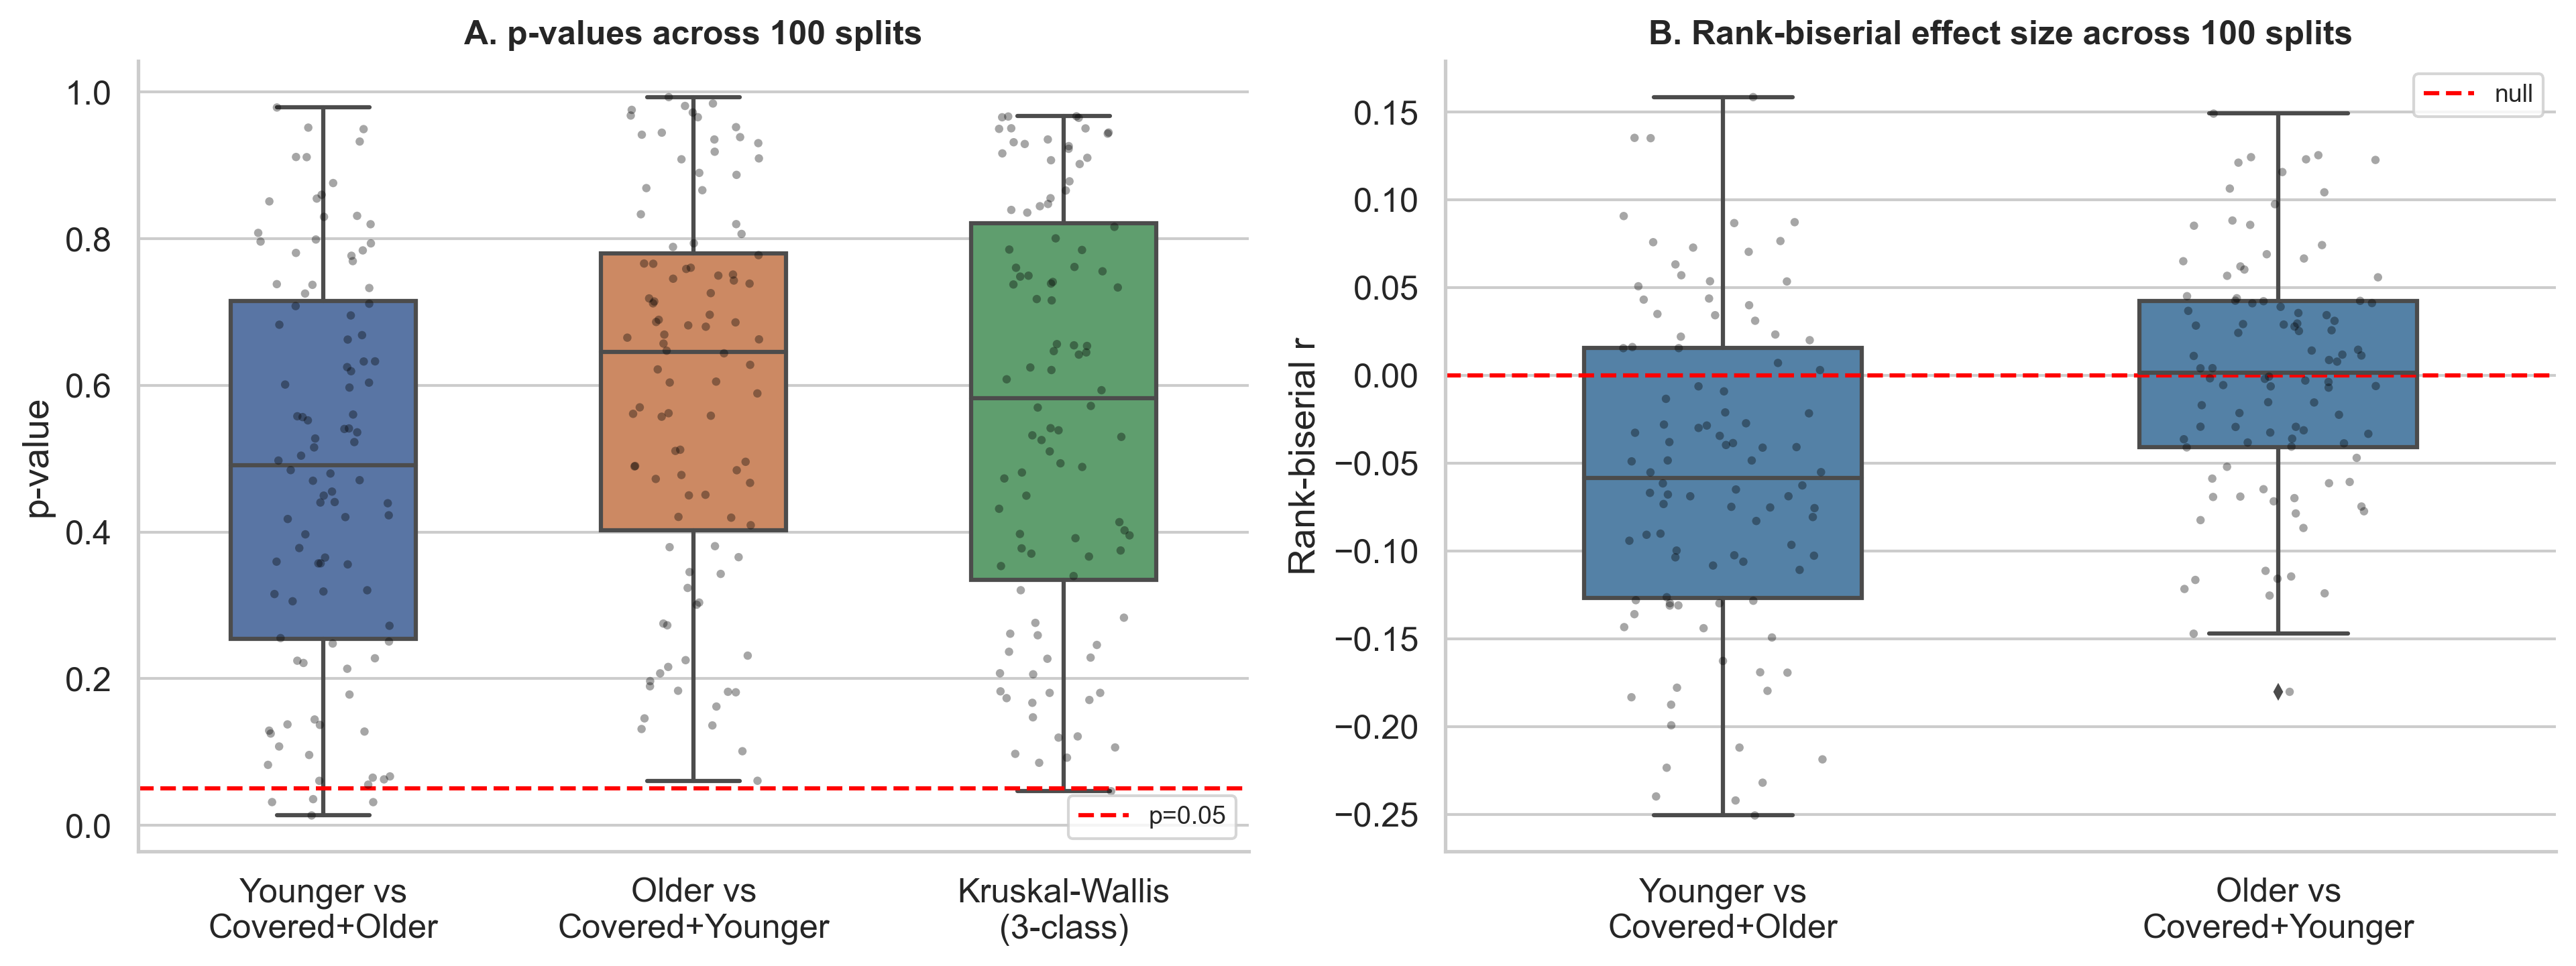

Representative split (median-p younger_vs_rest): seed=49


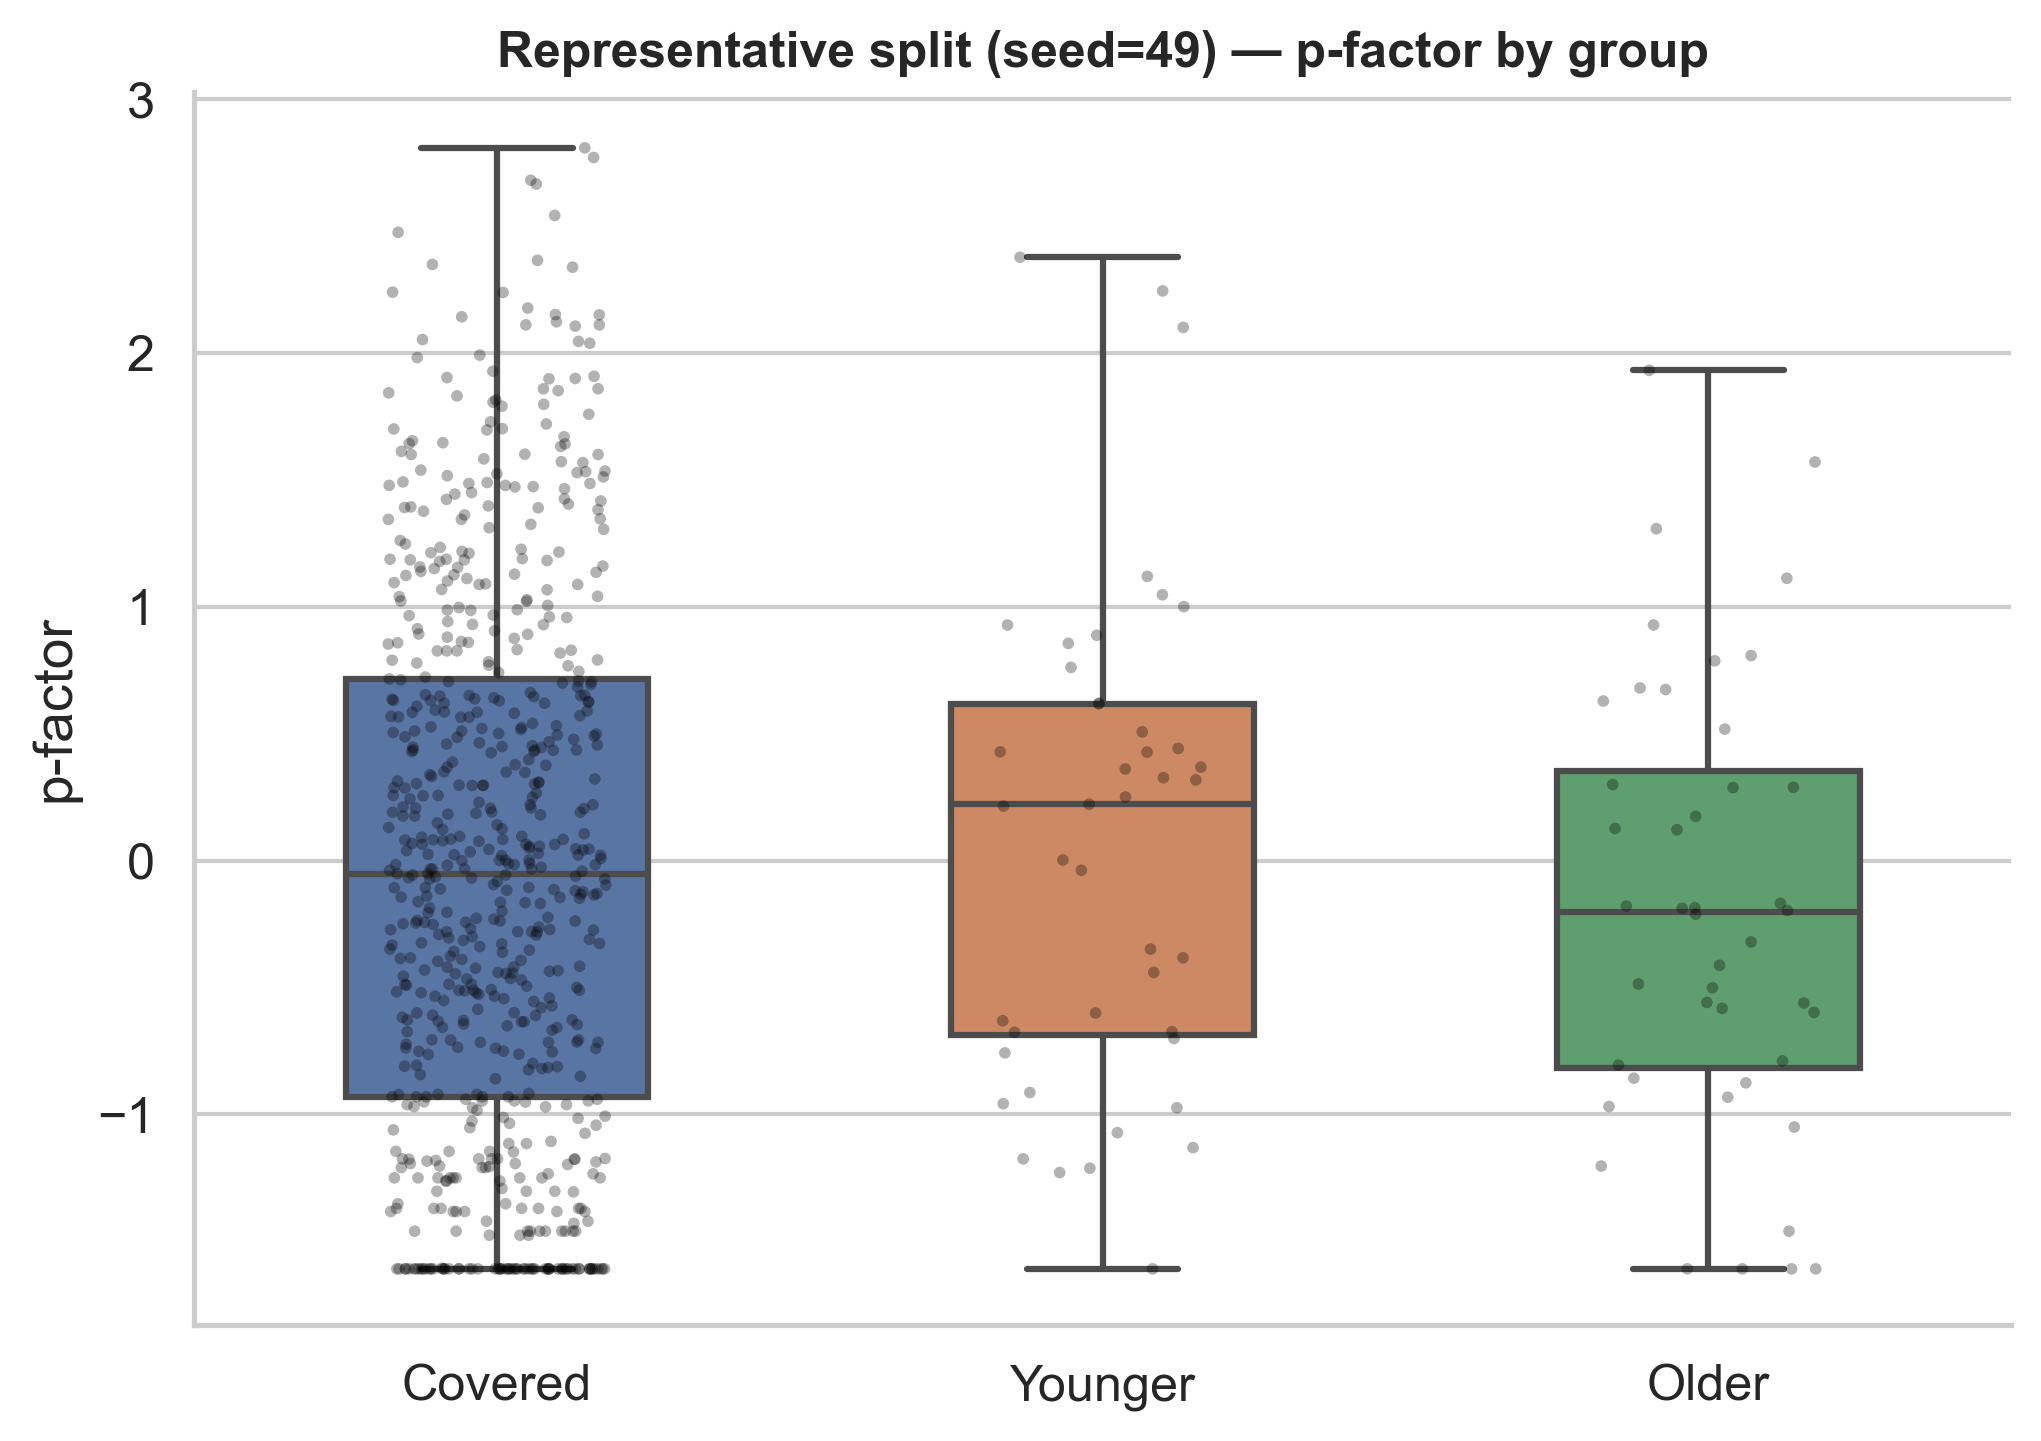

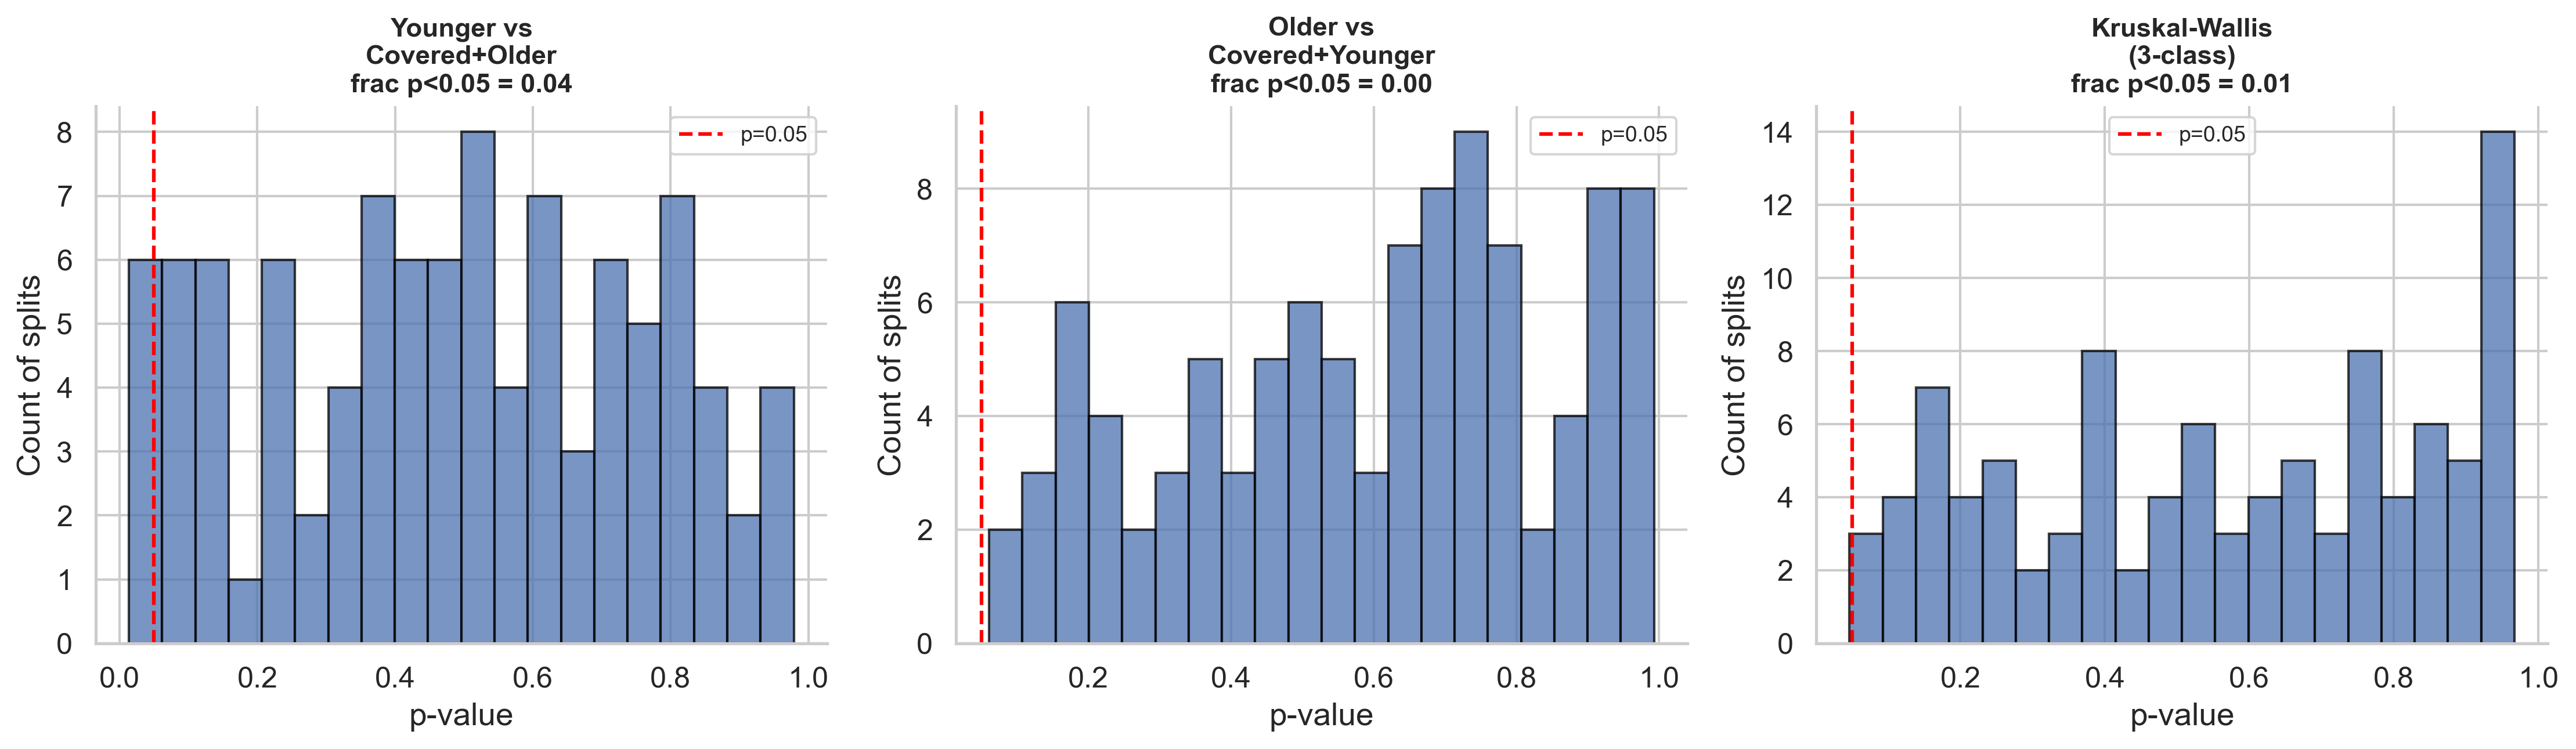

In [12]:
'''import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

contrast_order  = ["younger_vs_rest", "older_vs_rest", "kruskal_3class"]
contrast_labels = ["Younger vs\nCovered+Older",
                   "Older vs\nCovered+Younger",
                   "Kruskal-Wallis\n(3-class)"]

# ---------- Plot 1: p-values + effect sizes across 100 splits ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

sns.boxplot(data=split_results, x="contrast", y="p_mwu",
            order=contrast_order, ax=axes[0],
            width=0.5, linewidth=1.5, fliersize=3)
sns.stripplot(data=split_results, x="contrast", y="p_mwu",
              order=contrast_order, ax=axes[0],
              color="black", alpha=0.35, size=3, jitter=0.18)
axes[0].axhline(0.05, color="red", linestyle="--", linewidth=1.5, label="p=0.05")
axes[0].set_title("A. p-values across 100 splits", weight="bold", fontsize=12)
axes[0].set_xlabel(""); axes[0].set_ylabel("p-value")
axes[0].set_xticklabels(contrast_labels)
axes[0].legend(fontsize=9)

# Effect-size plot only uses the two binary MWU contrasts
binary_df = split_results[split_results["contrast"] != "kruskal_3class"]
sns.boxplot(data=binary_df, x="contrast", y="rb",
            order=contrast_order[:2], ax=axes[1],
            width=0.5, linewidth=1.5, fliersize=3, color="steelblue")
sns.stripplot(data=binary_df, x="contrast", y="rb",
              order=contrast_order[:2], ax=axes[1],
              color="black", alpha=0.35, size=3, jitter=0.18)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5, label="null")
axes[1].set_title("B. Rank-biserial effect size across 100 splits",
                  weight="bold", fontsize=12)
axes[1].set_xlabel(""); axes[1].set_ylabel("Rank-biserial r")
axes[1].set_xticklabels(contrast_labels[:2])
axes[1].legend(fontsize=9)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("pfactor_100splits_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------- Plot 2: representative-split boxplot of raw p-factor ----------
median_p = split_results.query("contrast == 'younger_vs_rest'")["p_mwu"].median()
yvr      = split_results.query("contrast == 'younger_vs_rest'").reset_index(drop=True)
rep_seed = int(yvr.iloc[(yvr["p_mwu"] - median_p).abs().argsort().iloc[0]]["seed"])
print(f"Representative split (median-p younger_vs_rest): seed={rep_seed}")

# Re-run that one split to recover raw values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=rep_seed)
cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=rep_seed)
lo_blocks, up_blocks = [], []
for tr_idx, val_idx in cv.split(X_tr):
    m = clone(ridge_model)
    m.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
    resid = np.abs(y_tr.iloc[val_idx].to_numpy() - m.predict(X_tr.iloc[val_idx]))
    yhat  = m.predict(X_te)
    lo_blocks.append(yhat[None, :] - resid[:, None])
    up_blocks.append(yhat[None, :] + resid[:, None])
lower = np.quantile(np.vstack(lo_blocks), ALPHA,     axis=0)
upper = np.quantile(np.vstack(up_blocks), 1 - ALPHA, axis=0)

y_arr  = y_te.to_numpy()
df_rep = df_combined.loc[y_te.index].copy()
df_rep["group_3class"] = np.where(
    (y_arr >= lower) & (y_arr <= upper), "Covered",
    np.where(y_arr > upper, "Older", "Younger")
)

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
group_order = ["Covered", "Younger", "Older"]
sns.boxplot(data=df_rep, x="group_3class", y=PF_COL, order=group_order,
            ax=ax, width=0.5, linewidth=1.5, fliersize=3)
sns.stripplot(data=df_rep, x="group_3class", y=PF_COL, order=group_order,
              ax=ax, color="black", alpha=0.30, size=2.8, jitter=0.18)
ax.set_title(f"Representative split (seed={rep_seed}) — p-factor by group",
             weight="bold", fontsize=12)
ax.set_xlabel(""); ax.set_ylabel("p-factor")
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("pfactor_representative_split.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------- Plot 3: histograms of p-values across 100 splits ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=300)

for ax, contrast, label in zip(axes, contrast_order, contrast_labels):
    pvals = split_results.query("contrast == @contrast")["p_mwu"].dropna()
    frac  = (pvals < 0.05).mean()
    ax.hist(pvals, bins=20, edgecolor="black", alpha=0.75)
    ax.axvline(0.05, color="red", linestyle="--", linewidth=1.5, label="p=0.05")
    ax.set_title(f"{label}\nfrac p<0.05 = {frac:.2f}", fontsize=11, weight="bold")
    ax.set_xlabel("p-value"); ax.set_ylabel("Count of splits")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("pfactor_pvalue_histograms.png", dpi=300, bbox_inches="tight")
plt.show()'''

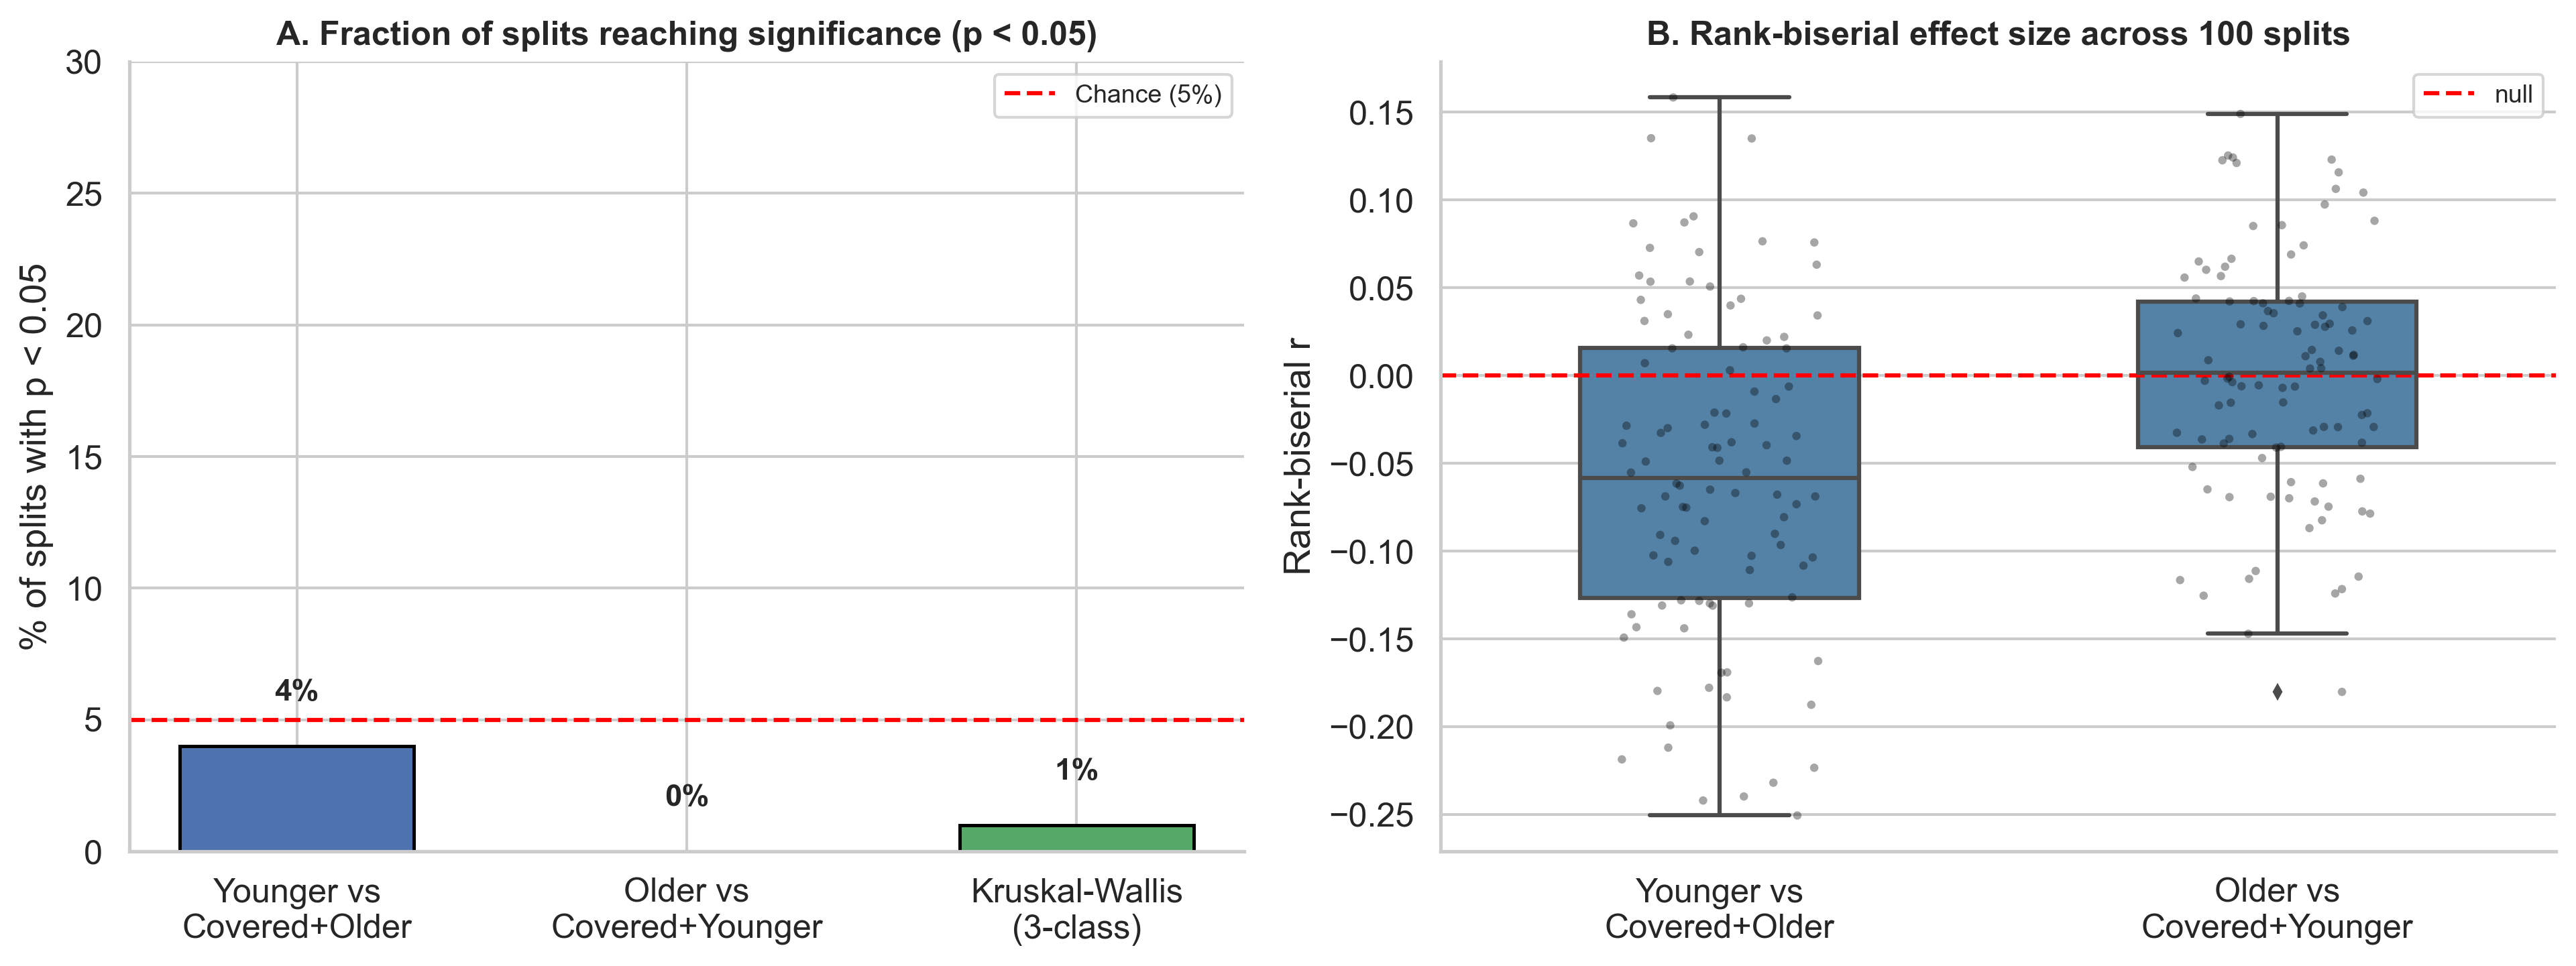

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

contrast_order  = ["younger_vs_rest", "older_vs_rest", "kruskal_3class"]
contrast_labels = ["Younger vs\nCovered+Older",
                   "Older vs\nCovered+Younger",
                   "Kruskal-Wallis\n(3-class)"]

# Compute % of splits with p < 0.05
frac_sig = (
    split_results
    .groupby("contrast")["p_mwu"]
    .apply(lambda x: (x < 0.05).mean() * 100)
    .reindex(contrast_order)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

# ---- Panel A: bar graph of % significant ----
bar_colors = ["#4C72B0", "#DD8452", "#55A868"]
bars = axes[0].bar(contrast_labels, frac_sig.values,
                   color=bar_colors, edgecolor="black", linewidth=1.2, width=0.6)

for bar, val in zip(bars, frac_sig.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 1.5,
                 f"{val:.0f}%", ha="center", va="bottom",
                 fontsize=11, weight="bold")

axes[0].axhline(5, color="red", linestyle="--", linewidth=1.5,
                label="Chance (5%)")
axes[0].set_ylim(0, max(frac_sig.max() + 10, 30))
axes[0].set_ylabel("% of splits with p < 0.05")
axes[0].set_title("A. Fraction of splits reaching significance (p < 0.05)",
                  weight="bold", fontsize=12)
axes[0].legend(fontsize=9, loc="upper right")

# ---- Panel B: rank-biserial effect sizes ----
binary_df = split_results[split_results["contrast"] != "kruskal_3class"]
sns.boxplot(data=binary_df, x="contrast", y="rb",
            order=contrast_order[:2], ax=axes[1],
            width=0.5, linewidth=1.5, fliersize=3, color="steelblue")
sns.stripplot(data=binary_df, x="contrast", y="rb",
              order=contrast_order[:2], ax=axes[1],
              color="black", alpha=0.35, size=3, jitter=0.18)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5, label="null")
axes[1].set_title("B. Rank-biserial effect size across 100 splits",
                  weight="bold", fontsize=12)
axes[1].set_xlabel(""); axes[1].set_ylabel("Rank-biserial r")
axes[1].set_xticklabels(contrast_labels[:2])
axes[1].legend(fontsize=9)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("pfactor_100splits_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

In [1]:
# ============================================================
# END-TO-END: load data → run Ridge CV+ across 100 splits →
# save p-value CSV → apply Bonferroni/BH → print counts
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from scipy.stats import mannwhitneyu, ttest_ind, kruskal
from statsmodels.stats.multitest import multipletests


# ============================================================
# 1. Load and merge datasets
# ============================================================

fc_path = "/Users/ujjwalsamanta/Desktop/HOMEWORK/PhDMUSC/MUSC/Sem2/LabRotation/combined_df_withinbetween_fcrsn7_artifact_pfactor_filter_harmonized.tsv"
gv_path = "/Users/ujjwalsamanta/Desktop/HOMEWORK/PhDMUSC/MUSC/Sem2/LabRotation/combined_df_gv_artifact_pfactor_filter_harmonized.tsv"
ct_path = "/Users/ujjwalsamanta/Desktop/HOMEWORK/PhDMUSC/MUSC/Sem2/LabRotation/combined_df_ct_artifact_pfactor_filter_harmonized.tsv"

df_fc = pd.read_csv(fc_path, sep="\t")
df_gv = pd.read_csv(gv_path, sep="\t")
df_ct = pd.read_csv(ct_path, sep="\t")

# Drop metadata from FC (keep merge keys + p_factor)
df_fc_cleaned = df_fc.drop(columns=[
    'study', 'study_site', 'session_id', 'wave', 'ethnicity', 'sex', 'race',
    'handedness', 'bmi', 'participant_education',
    'parent_1_education', 'parent_2_education',
    'internalizing_mcelroy_harmonized_all_samples',
    'externalizing_mcelroy_harmonized_all_samples',
    'attention_mcelroy_harmonized_all_samples',
    'cubids_acquisition_group', 'medianFD', 'meanFD'
])

# Keep 7Networks_ columns + merge keys for GV and CT
df_gv_cleaned = df_gv.loc[:, df_gv.columns.str.startswith('7Networks_') |
                             df_gv.columns.isin(['participant_id', 'p_factor_mcelroy_harmonized_all_samples', 'age'])]
df_ct_cleaned = df_ct.loc[:, df_ct.columns.str.startswith('7Networks_') |
                             df_ct.columns.isin(['participant_id', 'p_factor_mcelroy_harmonized_all_samples', 'age'])]

# Merge all three on participant_id + p_factor + age
df_combined = pd.merge(df_fc_cleaned, df_gv_cleaned,
                       on=['participant_id', 'p_factor_mcelroy_harmonized_all_samples', 'age'],
                       how='inner')
df_combined = pd.merge(df_combined, df_ct_cleaned,
                       on=['participant_id', 'p_factor_mcelroy_harmonized_all_samples', 'age'],
                       how='inner')

print(f"Merged shape: {df_combined.shape}")


# ============================================================
# 2. Prepare X, y
# ============================================================

target_col = 'age'
X = df_combined.drop(columns=[target_col, 'participant_id',
                              'p_factor_mcelroy_harmonized_all_samples'])
y = df_combined[target_col]

print(f"X shape: {X.shape}, y shape: {y.shape}")


# ============================================================
# 3. Define Ridge model
# ============================================================

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 30)))
])


# ============================================================
# 4. Run 100-split CV+ + all three contrasts
# ============================================================

N_SPLITS = 100
ALPHA    = 0.1
N_FOLDS  = 5
PF_COL   = "p_factor_mcelroy_harmonized_all_samples"


def rank_biserial(U, n1, n2):
    return 1 - 2 * U / (n1 * n2)


def run_contrast(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) < 2 or len(b) < 2:
        return dict(n1=len(a), n2=len(b), U=np.nan, p_mwu=np.nan,
                    rb=np.nan, t=np.nan, p_t=np.nan,
                    med_a=np.nan, med_b=np.nan,
                    mean_a=np.nan, mean_b=np.nan)
    mwu = mannwhitneyu(a, b, alternative="two-sided")
    tt  = ttest_ind(a, b, equal_var=False)
    return dict(n1=len(a), n2=len(b),
                U=float(mwu.statistic), p_mwu=float(mwu.pvalue),
                rb=float(rank_biserial(mwu.statistic, len(a), len(b))),
                t=float(tt.statistic), p_t=float(tt.pvalue),
                med_a=float(np.median(a)), med_b=float(np.median(b)),
                mean_a=float(np.mean(a)),  mean_b=float(np.mean(b)))


records = []
for seed in range(N_SPLITS):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)
    cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

    lo_blocks, up_blocks = [], []
    for tr_idx, val_idx in cv.split(X_tr):
        m = clone(ridge_model)
        m.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
        resid = np.abs(y_tr.iloc[val_idx].to_numpy() - m.predict(X_tr.iloc[val_idx]))
        yhat  = m.predict(X_te)
        lo_blocks.append(yhat[None, :] - resid[:, None])
        up_blocks.append(yhat[None, :] + resid[:, None])

    lower = np.quantile(np.vstack(lo_blocks), ALPHA,     axis=0)
    upper = np.quantile(np.vstack(up_blocks), 1 - ALPHA, axis=0)

    y_arr   = y_te.to_numpy()
    covered = (y_arr >= lower) & (y_arr <= upper)
    older   = y_arr > upper
    younger = y_arr < lower

    df_te   = df_combined.loc[y_te.index]
    pf_vals = df_te[PF_COL].to_numpy()
    ok      = ~pd.isna(pf_vals)

    n_cov = int(covered.sum()); n_yng = int(younger.sum()); n_old = int(older.sum())

    # younger vs (covered + older)
    r = run_contrast(pf_vals[younger & ok], pf_vals[~younger & ok])
    records.append({"seed": seed, "contrast": "younger_vs_rest", **r,
                    "n_covered": n_cov, "n_younger": n_yng, "n_older": n_old})

    # older vs (covered + younger)
    r = run_contrast(pf_vals[older & ok], pf_vals[~older & ok])
    records.append({"seed": seed, "contrast": "older_vs_rest", **r,
                    "n_covered": n_cov, "n_younger": n_yng, "n_older": n_old})

    # 3-class Kruskal-Wallis
    cov_vals = pf_vals[covered & ok]
    yng_vals = pf_vals[younger & ok]
    old_vals = pf_vals[older   & ok]
    if len(cov_vals) > 1 and len(yng_vals) > 1 and len(old_vals) > 1:
        kw = kruskal(cov_vals, yng_vals, old_vals)
        kw_p = float(kw.pvalue)
    else:
        kw_p = np.nan
    records.append({"seed": seed, "contrast": "kruskal_3class",
                    "n1": n_cov + n_yng + n_old, "n2": np.nan,
                    "U": np.nan, "p_mwu": kw_p,
                    "rb": np.nan, "t": np.nan, "p_t": np.nan,
                    "med_a": np.nan, "med_b": np.nan,
                    "mean_a": np.nan, "mean_b": np.nan,
                    "n_covered": n_cov, "n_younger": n_yng, "n_older": n_old})

    if (seed + 1) % 10 == 0:
        print(f"  finished split {seed + 1}/{N_SPLITS}")

split_results = pd.DataFrame(records)
split_results.to_csv("pfactor_comparisons_100splits.csv", index=False)
print(f"\nSaved: pfactor_comparisons_100splits.csv, shape {split_results.shape}")


# ============================================================
# 5. Apply Bonferroni and BH correction across the 3 tests per split
# ============================================================

pvals_wide = split_results.pivot(index="seed", columns="contrast", values="p_mwu")
contrasts = ["younger_vs_rest", "older_vs_rest", "kruskal_3class"]
pvals_wide = pvals_wide[contrasts]

bonf_sig = np.zeros_like(pvals_wide.values, dtype=bool)
bh_sig   = np.zeros_like(pvals_wide.values, dtype=bool)

for i, row in enumerate(pvals_wide.values):
    bonf_sig[i, :] = multipletests(row, alpha=0.05, method="bonferroni")[0]
    bh_sig[i, :]   = multipletests(row, alpha=0.05, method="fdr_bh")[0]

print("\n" + "=" * 60)
print("Splits with p < 0.05 (out of 100)")
print("=" * 60)

print("\nUncorrected:")
for j, c in enumerate(contrasts):
    print(f"  {c}: {(pvals_wide[c] < 0.05).sum()}/100")

print("\nBonferroni (across 3 tests per split):")
for j, c in enumerate(contrasts):
    print(f"  {c}: {bonf_sig[:, j].sum()}/100")

print("\nBenjamini-Hochberg / FDR (across 3 tests per split):")
for j, c in enumerate(contrasts):
    print(f"  {c}: {bh_sig[:, j].sum()}/100")

/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_95004/2687751128.py:27: DtypeWarning: Columns (405) have mixed types. Specify dtype option on import or set low_memory=False.
  df_gv = pd.read_csv(gv_path, sep="\t")
/var/folders/6s/hdwy5qm16y7grjqwnqg7blxh0000gn/T/ipykernel_95004/2687751128.py:28: DtypeWarning: Columns (405) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ct = pd.read_csv(ct_path, sep="\t")


Merged shape: (3762, 831)
X shape: (3762, 828), y shape: (3762,)
  finished split 10/100
  finished split 20/100
  finished split 30/100
  finished split 40/100
  finished split 50/100
  finished split 60/100
  finished split 70/100
  finished split 80/100
  finished split 90/100
  finished split 100/100

Saved: pfactor_comparisons_100splits.csv, shape (300, 16)

Splits with p < 0.05 (out of 100)

Uncorrected:
  younger_vs_rest: 4/100
  older_vs_rest: 0/100
  kruskal_3class: 1/100

Bonferroni (across 3 tests per split):
  younger_vs_rest: 1/100
  older_vs_rest: 0/100
  kruskal_3class: 0/100

Benjamini-Hochberg / FDR (across 3 tests per split):
  younger_vs_rest: 1/100
  older_vs_rest: 0/100
  kruskal_3class: 0/100


In [2]:
n_none_rejected = (~bh_sig).all(axis=1).sum()
print(f"Splits with no test rejected after BH: {n_none_rejected}/100")

Splits with no test rejected after BH: 99/100


In [12]:
from statsmodels.stats.multitest import multipletests
import numpy as np

pvals_wide = split_results.pivot(index="seed", columns="contrast", values="p_mwu")
contrasts_2 = ["older_vs_rest", "younger_vs_rest"]
pv2 = pvals_wide[contrasts_2]

bh_sig_2 = np.zeros_like(pv2.values, dtype=bool)
for i, row in enumerate(pv2.values):
    bh_sig_2[i, :] = multipletests(row, alpha=0.05, method="fdr_bh")[0]

print("p-factor BH across 2 tests (Kruskal dropped):")
for j, c in enumerate(contrasts_2):
    print(f"  {c}: {bh_sig_2[:, j].sum()}/100")

p-factor BH across 2 tests (Kruskal dropped):
  older_vs_rest: 0/100
  younger_vs_rest: 1/100


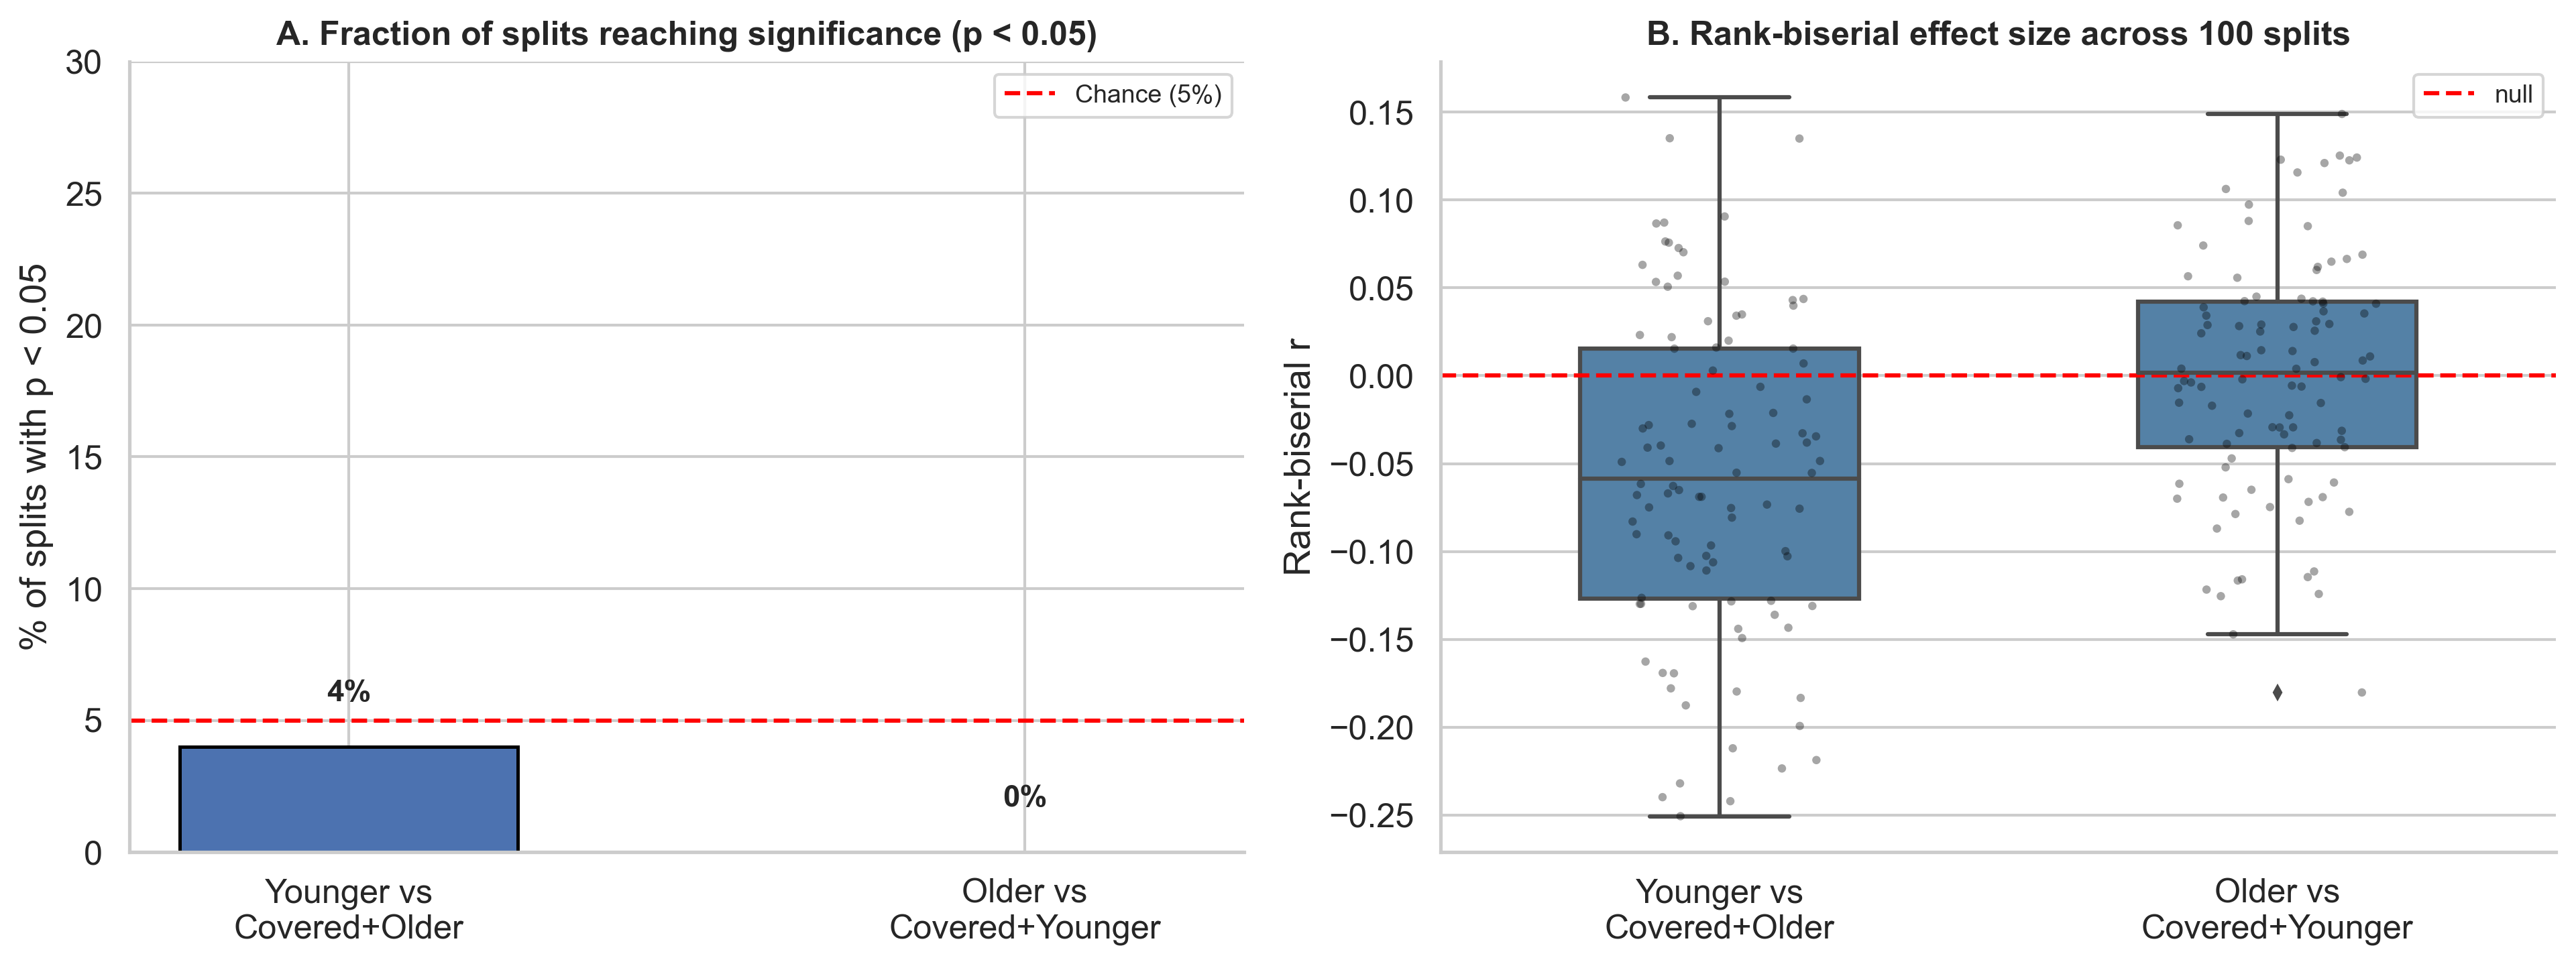

Saved: /Users/ujjwalsamanta/Desktop/figure4_pfactor_100splits.png


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

# Only 2 contrasts now (Kruskal removed)
contrast_order  = ["younger_vs_rest", "older_vs_rest"]
contrast_labels = ["Younger vs\nCovered+Older",
                   "Older vs\nCovered+Younger"]

# Compute % of splits with p < 0.05
frac_sig = (
    split_results
    .groupby("contrast")["p_mwu"]
    .apply(lambda x: (x < 0.05).mean() * 100)
    .reindex(contrast_order)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

# ---- Panel A: bar graph of % significant ----
bar_colors = ["#4C72B0", "#DD8452"]
bars = axes[0].bar(contrast_labels, frac_sig.values,
                   color=bar_colors, edgecolor="black", linewidth=1.2, width=0.5)

for bar, val in zip(bars, frac_sig.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 1.5,
                 f"{val:.0f}%", ha="center", va="bottom",
                 fontsize=11, weight="bold")

axes[0].axhline(5, color="red", linestyle="--", linewidth=1.5,
                label="Chance (5%)")
axes[0].set_ylim(0, max(frac_sig.max() + 10, 30))
axes[0].set_ylabel("% of splits with p < 0.05")
axes[0].set_title("A. Fraction of splits reaching significance (p < 0.05)",
                  weight="bold", fontsize=12)
axes[0].legend(fontsize=9, loc="upper right")

# ---- Panel B: rank-biserial effect sizes ----
binary_df = split_results[split_results["contrast"].isin(contrast_order)]
sns.boxplot(data=binary_df, x="contrast", y="rb",
            order=contrast_order, ax=axes[1],
            width=0.5, linewidth=1.5, fliersize=3, color="steelblue")
sns.stripplot(data=binary_df, x="contrast", y="rb",
              order=contrast_order, ax=axes[1],
              color="black", alpha=0.35, size=3, jitter=0.18)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5, label="null")
axes[1].set_title("B. Rank-biserial effect size across 100 splits",
                  weight="bold", fontsize=12)
axes[1].set_xlabel(""); axes[1].set_ylabel("Rank-biserial r")
axes[1].set_xticklabels(contrast_labels)
axes[1].legend(fontsize=9)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()

# Save to Desktop
png_path = "/Users/ujjwalsamanta/Desktop/figure4_pfactor_100splits.png"
plt.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")

plt.show()
print(f"Saved: {png_path}")

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.base import clone

SEEDS = list(range(100))
ALPHA = 0.1
N_FOLDS = 5
BIN_WIDTH = 2

coverage_results = []

for seed in SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)
    cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

    lo_blocks, up_blocks = [], []
    for tr_idx, val_idx in cv.split(X_tr):
        m = clone(ridge_model)
        m.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
        resid = np.abs(y_tr.iloc[val_idx].to_numpy() - m.predict(X_tr.iloc[val_idx]))
        yhat  = m.predict(X_te)
        lo_blocks.append(yhat[None, :] - resid[:, None])
        up_blocks.append(yhat[None, :] + resid[:, None])

    lower = np.quantile(np.vstack(lo_blocks), ALPHA,     axis=0)
    upper = np.quantile(np.vstack(up_blocks), 1 - ALPHA, axis=0)

    y_arr = y_te.to_numpy()
    covered_mask = (y_arr >= lower) & (y_arr <= upper)

    min_age = int(np.floor(y_arr.min()))
    max_age = int(np.ceil(y_arr.max()))
    bins = np.arange(min_age, max_age + BIN_WIDTH, BIN_WIDTH)
    age_bins = pd.cut(y_arr, bins=bins)

    temp = pd.DataFrame({"age": y_arr, "covered": covered_mask, "age_bin": age_bins})
    grouped = temp.groupby("age_bin", observed=True)["covered"]
    cov_per_bin = grouped.mean()
    n_per_bin   = grouped.count()

    for bin_label in cov_per_bin.index:
        coverage_results.append({
            "seed": seed,
            "age_bin": str(bin_label),
            "coverage": cov_per_bin[bin_label],
            "n": int(n_per_bin[bin_label]),
        })

    if (seed + 1) % 10 == 0:
        print(f"  finished split {seed + 1}/100")

df_cov = pd.DataFrame(coverage_results)
print(df_cov.head())

  finished split 10/100
  finished split 20/100
  finished split 30/100
  finished split 40/100
  finished split 50/100
  finished split 60/100
  finished split 70/100
  finished split 80/100
  finished split 90/100
  finished split 100/100
   seed   age_bin  coverage    n
0     0    (6, 8]  0.849315   73
1     0   (8, 10]  0.889706  136
2     0  (10, 12]  0.936709  158
3     0  (12, 14]  0.940171  117
4     0  (14, 16]  0.945652   92


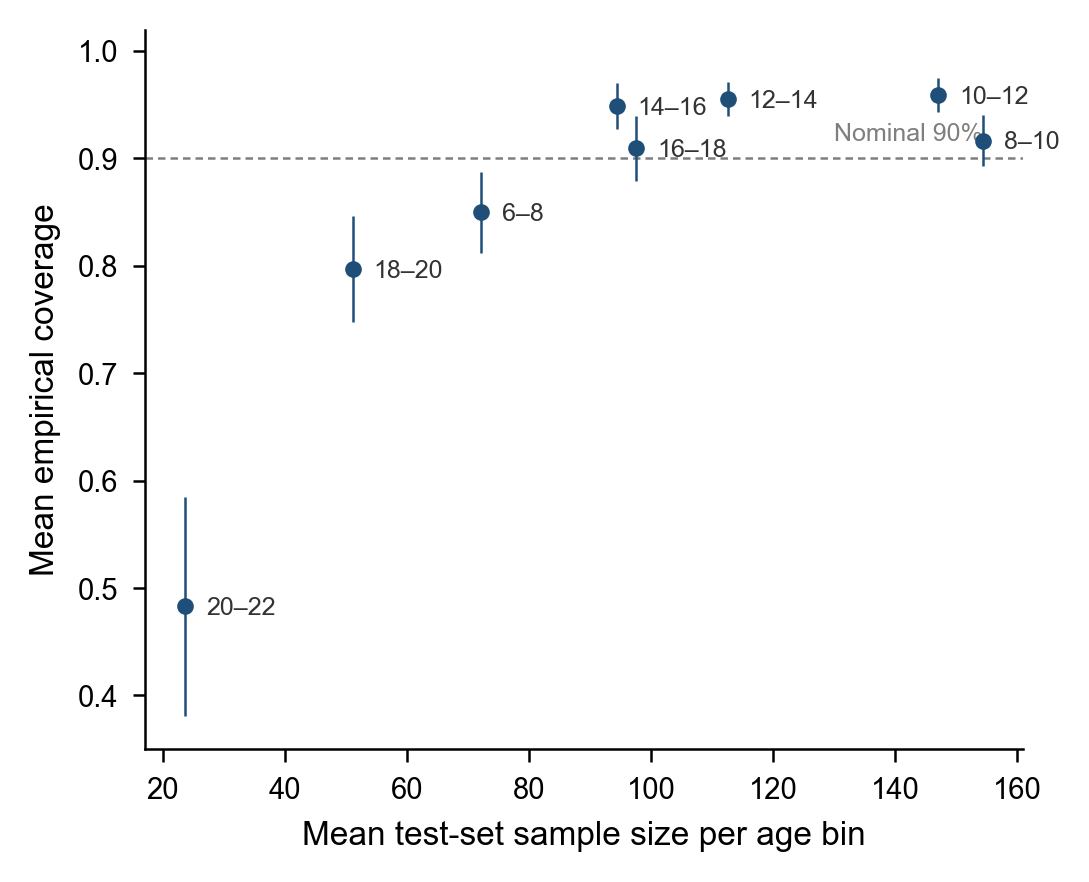

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

summary = (df_cov.groupby("age_bin", observed=True)
                 .agg(mean_coverage=("coverage", "mean"),
                      sd_coverage=("coverage", "std"),
                      mean_n=("n", "mean"))
                 .reset_index())
summary["bin_start"] = summary["age_bin"].str.extract(r"\((\d+)").astype(int)
summary = summary.sort_values("bin_start").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(3.5, 2.8), dpi=300)

ax.errorbar(summary["mean_n"], summary["mean_coverage"],
            yerr=summary["sd_coverage"],
            fmt="o", color="#1f4e79", ecolor="#1f4e79",
            capsize=1.8, capthick=0.6,
            markersize=4, markeredgewidth=0,
            elinewidth=0.6, zorder=3)

ax.axhline(0.90, linestyle=(0, (3, 2)), color="#7f7f7f",
           linewidth=0.6, zorder=1)

for _, r in summary.iterrows():
    label = r["age_bin"].replace("(", "").replace("]", "").replace(", ", "–")
    ax.annotate(label, (r["mean_n"], r["mean_coverage"]),
                xytext=(5, -2), textcoords="offset points",
                fontsize=6, color="#333", zorder=4)

ax.annotate("Nominal 90%", xy=(summary["mean_n"].max(), 0.90),
            xytext=(0, 3), textcoords="offset points",
            ha="right", va="bottom", fontsize=6, color="#7f7f7f")

ax.set_xlabel("Mean test-set sample size per age bin")
ax.set_ylabel("Mean empirical coverage")
ax.set_ylim(0.35, 1.02)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(pad=0.3)
plt.savefig("figure3B_coverage_vs_n.png", dpi=600,
            bbox_inches="tight", facecolor="white")
plt.savefig("figure3B_coverage_vs_n.pdf",
            bbox_inches="tight", facecolor="white")
plt.show()

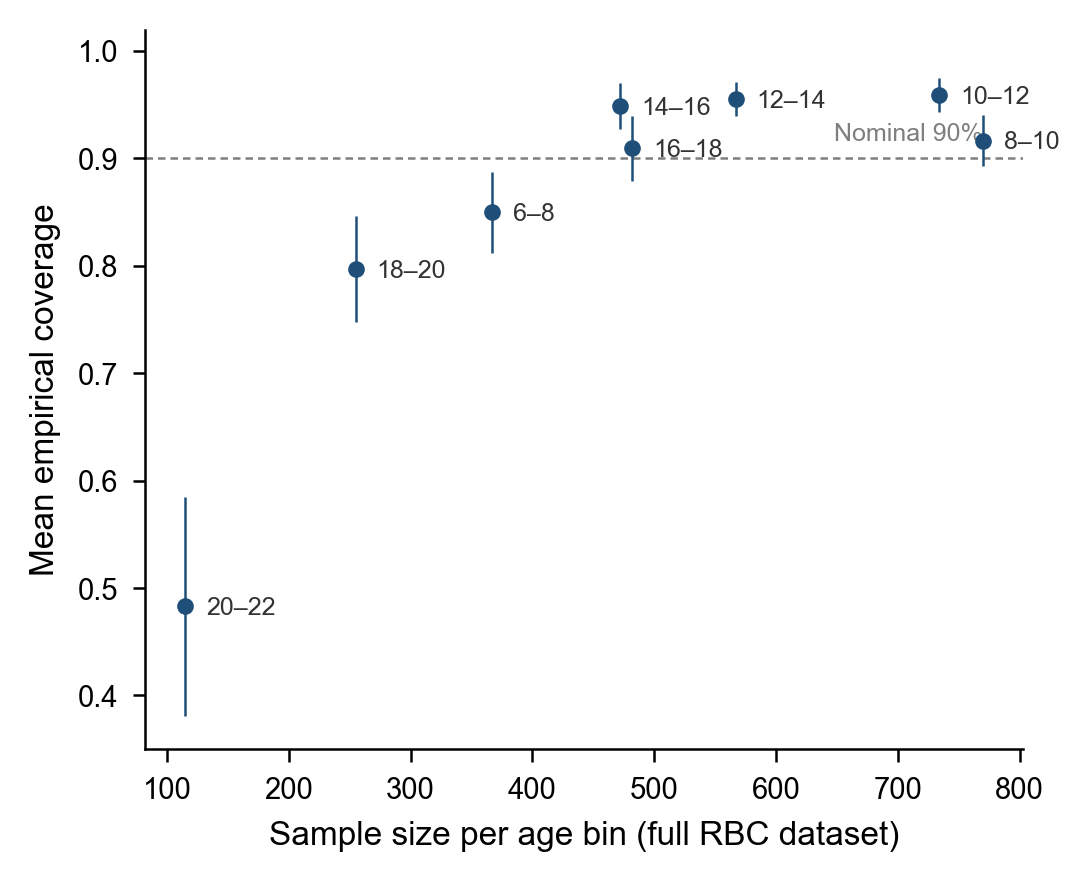

Saved: /Users/ujjwalsamanta/Desktop/figure3B_coverage_vs_n.png
Saved: /Users/ujjwalsamanta/Desktop/figure3B_coverage_vs_n.pdf


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# ----- Coverage summary from df_cov (across 100 splits) -----
cov_summary = (df_cov.groupby("age_bin", observed=True)
                     .agg(mean_coverage=("coverage", "mean"),
                          sd_coverage=("coverage", "std"))
                     .reset_index())

# ----- Sample size per age bin from FULL dataset -----
BIN_WIDTH = 2
min_age = int(np.floor(df_combined["age"].min()))
max_age = int(np.ceil(df_combined["age"].max()))
bins = np.arange(min_age, max_age + BIN_WIDTH, BIN_WIDTH)
df_combined_bins = pd.cut(df_combined["age"], bins=bins)
full_n_per_bin = df_combined_bins.value_counts().sort_index()
full_n_df = full_n_per_bin.rename_axis("age_bin").reset_index(name="full_n")
full_n_df["age_bin"] = full_n_df["age_bin"].astype(str)

# ----- Merge -----
summary = cov_summary.merge(full_n_df, on="age_bin")
summary["bin_start"] = summary["age_bin"].str.extract(r"\((\d+)").astype(int)
summary = summary.sort_values("bin_start").reset_index(drop=True)

# ----- Plot -----
fig, ax = plt.subplots(figsize=(3.5, 2.8), dpi=300)

ax.errorbar(summary["full_n"], summary["mean_coverage"],
            yerr=summary["sd_coverage"],
            fmt="o", color="#1f4e79", ecolor="#1f4e79",
            capsize=1.8, capthick=0.6,
            markersize=4, markeredgewidth=0,
            elinewidth=0.6, zorder=3)

ax.axhline(0.90, linestyle=(0, (3, 2)), color="#7f7f7f",
           linewidth=0.6, zorder=1)

for _, r in summary.iterrows():
    label = r["age_bin"].replace("(", "").replace("]", "").replace(", ", "–")
    ax.annotate(label, (r["full_n"], r["mean_coverage"]),
                xytext=(5, -2), textcoords="offset points",
                fontsize=6, color="#333", zorder=4)

ax.annotate("Nominal 90%", xy=(summary["full_n"].max(), 0.90),
            xytext=(0, 3), textcoords="offset points",
            ha="right", va="bottom", fontsize=6, color="#7f7f7f")

ax.set_xlabel("Sample size per age bin (full RBC dataset)")
ax.set_ylabel("Mean empirical coverage")
ax.set_ylim(0.35, 1.02)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(pad=0.3)

# ----- Save to Desktop (change path if you want elsewhere) -----
png_path = "/Users/ujjwalsamanta/Desktop/figure3B_coverage_vs_n.png"
pdf_path = "/Users/ujjwalsamanta/Desktop/figure3B_coverage_vs_n.pdf"

plt.savefig(png_path, dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(pdf_path, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")